# VSE Quantitative Analysis

**Goal:** Vascular Super-Enhancement (VSE) increases contrast between vasculature
and surrounding tissue without degrading image quality.

This notebook evaluates two claims:
1. **CNR is improved** — VSE increases contrast-to-noise ratio between vessels (Ao, IVS, PA) and air.
2. **SNR is preserved** — VSE does not degrade signal-to-noise ratio in any region.

In [133]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import Patch

NOTEBOOK_DIR = Path.home() / "vascular-superenhancement-4d-flow" / "notebooks" / "analysis" / "VSE_quantitative_analysis"
CSV_PATH = NOTEBOOK_DIR / "consolidated.csv"

# ── Global plot theme (edit this cell to restyle all figures) ──
COLORS = {"normal": "white", "vse": "black"}
LABELS = {"normal": "Baseline", "vse": "Enhanced"}
REGION_LABELS = {"Ao": "Aorta", "PA": "Pulmonary Artery", "IVS": "Myocardium", "Air": "Air"}

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 150,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": True,
    "axes.grid.axis": "y",
    "grid.alpha": 0.3,
    "grid.linewidth": 0.5,
})

BOXPLOT_KW = dict(
    patch_artist=True,
    showmeans=True,
    meanprops=dict(marker="D", markerfacecolor="white", markeredgecolor="#333",
                   markersize=5, zorder=5),
    boxprops=dict(linewidth=1.2, edgecolor="#333"),
    whiskerprops=dict(linewidth=1.0, linestyle="-"),
    capprops=dict(linewidth=1.0),
    medianprops=dict(color="#2d2d2d", linewidth=1.5),
    flierprops=dict(marker="o", markerfacecolor="none", markeredgecolor="#888",
                    markersize=5, alpha=0.7),
)

def color_boxes(bp, colors):
    """Apply face colors to box plot patches."""
    for box, c in zip(bp["boxes"], colors):
        box.set_facecolor(c)
        box.set_alpha(0.85)

LEGEND_HANDLES = [
    Patch(facecolor=COLORS["normal"], edgecolor="#333", alpha=0.85, label=LABELS["normal"]),
    Patch(facecolor=COLORS["vse"], edgecolor="#333", alpha=0.85, label=LABELS["vse"]),
]

data = pd.read_csv(CSV_PATH)
print(f"{len(data)} rows  |  {data['patient'].nunique()} patients  |  "
      f"{sorted(data['region'].unique())}  |  {sorted(data['reconstruction'].unique())}")
data.head()

2360 rows  |  15 patients  |  ['Air', 'Ao', 'IVS', 'PA']  |  ['normal', 'vse']


,patient,region,reconstruction,timepoint,mean,std,snr
0,Balboloop,Ao,normal,1,1452.38,67.66,21.465859
1,Balboloop,Ao,normal,2,1399.85,80.98,17.286367
2,Balboloop,Ao,normal,3,1329.10,85.26,15.588787
3,Balboloop,Ao,normal,4,1279.85,55.08,23.236202
4,Balboloop,Ao,normal,5,1234.62,34.42,35.869262


## Data cleaning

Drop timepoints with anomalous SNR (> 100). The 99.5th percentile of SNR across
the dataset is ~54; all 6 values above 100 come from Golotag/PA/vse timepoints 4–9
where the viewer reported near-zero std (confirmed on re-inspection — likely the ROI
overlapping a very homogeneous patch during those cardiac phases).

In [134]:
SNR_OUTLIER_THRESHOLD = 100

outlier_mask = data["snr"] > SNR_OUTLIER_THRESHOLD
n_dropped = outlier_mask.sum()

if n_dropped:
    print(f"Dropping {n_dropped} timepoints with SNR > {SNR_OUTLIER_THRESHOLD}:")
    print(data[outlier_mask][["patient", "region", "reconstruction", "timepoint", "std", "snr"]].to_string(index=False))
else:
    print("No SNR outliers detected.")

data = data[~outlier_mask].reset_index(drop=True)
print(f"\n{len(data)} rows remaining")

Dropping 6 timepoints with SNR > 100:
patient region reconstruction  timepoint   std          snr
Golotag     PA            vse          4 13.00   602.797692
Golotag     PA            vse          5  0.45 17497.600000
Golotag     PA            vse          6 31.99   247.660519
Golotag     PA            vse          7 55.00   143.376545
Golotag     PA            vse          8 34.83   222.321849
Golotag     PA            vse          9 41.59   187.152200

2354 rows remaining


## Derived metrics

Compute time-averaged SNR and CNR for downstream analyses.

In [135]:
regions = sorted(data["region"].unique())
vessel_regions = [r for r in regions if r != "Air"]
cnr_regions = ["Ao", "PA"]  # CNR only meaningful for vascular lumen, not IVS

# --- Time-averaged SNR per (patient, region, reconstruction) ---
snr_avg = (
    data.groupby(["patient", "region", "reconstruction"])["snr"]
    .mean()
    .reset_index()
    .rename(columns={"snr": "snr_mean"})
)

snr_pivot = snr_avg.pivot_table(
    index=["patient", "region"],
    columns="reconstruction",
    values="snr_mean",
)
snr_pivot["vse_minus_normal"] = snr_pivot["vse"] - snr_pivot["normal"]
snr_pivot["vse_over_normal"] = snr_pivot["vse"] / snr_pivot["normal"]

# --- CNR_air: (mean_vessel - mean_air) / std_air ---
air = data[data["region"] == "Air"][["patient", "reconstruction", "timepoint", "mean", "std"]].rename(
    columns={"mean": "air_mean", "std": "air_std"}
)
vessels = data[data["region"].isin(cnr_regions)].copy()
cnr_air_data = vessels.merge(air, on=["patient", "reconstruction", "timepoint"], how="inner")
cnr_air_data["cnr"] = (cnr_air_data["mean"] - cnr_air_data["air_mean"]) / cnr_air_data["air_std"]

cnr_air_avg = (
    cnr_air_data.groupby(["patient", "region", "reconstruction"])["cnr"]
    .mean().reset_index().rename(columns={"cnr": "cnr_mean"})
)
cnr_air_pivot = cnr_air_avg.pivot_table(index=["patient", "region"], columns="reconstruction", values="cnr_mean")
cnr_air_pivot["vse_minus_normal"] = cnr_air_pivot["vse"] - cnr_air_pivot["normal"]
cnr_air_pivot["vse_over_normal"] = cnr_air_pivot["vse"] / cnr_air_pivot["normal"]

# --- CNR_myo: (mean_vessel - mean_IVS) / std_IVS ---
ivs = data[data["region"] == "IVS"][["patient", "reconstruction", "timepoint", "mean", "std"]].rename(
    columns={"mean": "ivs_mean", "std": "ivs_std"}
)
cnr_myo_data = vessels.merge(ivs, on=["patient", "reconstruction", "timepoint"], how="inner")
cnr_myo_data["cnr"] = (cnr_myo_data["mean"] - cnr_myo_data["ivs_mean"]) / cnr_myo_data["ivs_std"]

cnr_myo_avg = (
    cnr_myo_data.groupby(["patient", "region", "reconstruction"])["cnr"]
    .mean().reset_index().rename(columns={"cnr": "cnr_mean"})
)
cnr_myo_pivot = cnr_myo_avg.pivot_table(index=["patient", "region"], columns="reconstruction", values="cnr_mean")
cnr_myo_pivot["vse_minus_normal"] = cnr_myo_pivot["vse"] - cnr_myo_pivot["normal"]
cnr_myo_pivot["vse_over_normal"] = cnr_myo_pivot["vse"] / cnr_myo_pivot["normal"]

# --- Time-averaged mean SI ---
si_avg = (
    data.groupby(["patient", "region", "reconstruction"])["mean"]
    .mean()
    .reset_index()
    .rename(columns={"mean": "si_mean"})
)

print(f"SNR: {len(snr_avg)} entries  |  CNR_air: {len(cnr_air_avg)}, CNR_myo: {len(cnr_myo_avg)} entries  |  SI: {len(si_avg)} entries")

SNR: 118 entries  |  CNR_air: 58, CNR_myo: 58 entries  |  SI: 118 entries


In [136]:
from scipy import stats as sp_stats

def _paired_stats(pivot_df, metric_name, region_list=None):
    """Run paired tests for each region and return a summary DataFrame."""
    if region_list is None:
        region_list = cnr_regions
    rows = []
    for region in region_list:
        pdf = pivot_df.reset_index()
        sub = pdf[pdf["region"] == region].dropna(subset=["normal", "vse"])
        normal = sub["normal"].values
        vse = sub["vse"].values
        diff = vse - normal
        n = len(diff)

        shapiro_stat, shapiro_p = sp_stats.shapiro(diff)
        wilcoxon_stat, wilcoxon_p = sp_stats.wilcoxon(diff)
        ttest_stat, ttest_p = sp_stats.ttest_rel(vse, normal)
        cohens_d = diff.mean() / diff.std()

        rows.append({
            "metric": metric_name,
            "region": region,
            "n": n,
            "normal_mean": normal.mean(),
            "vse_mean": vse.mean(),
            "diff_mean": diff.mean(),
            "diff_std": diff.std(),
            "shapiro_p": shapiro_p,
            "wilcoxon_p": wilcoxon_p,
            "ttest_p": ttest_p,
            "cohens_d": cohens_d,
        })
    return pd.DataFrame(rows)

def _sig(p):
    if p < 0.001: return "***"
    if p < 0.01: return "**"
    if p < 0.05: return "*"
    return "ns"

stats_results = pd.concat([
    _paired_stats(cnr_air_pivot, "CNR_air"),
    _paired_stats(cnr_myo_pivot, "CNR_myo"),
    _paired_stats(snr_pivot, "SNR", region_list=cnr_regions),
], ignore_index=True)

stats_results["wilcoxon_sig"] = stats_results["wilcoxon_p"].apply(_sig)

def _get_sig(metric, region):
    """Look up the Wilcoxon significance string for a metric/region."""
    row = stats_results[(stats_results["metric"] == metric) & (stats_results["region"] == region)]
    p = row["wilcoxon_p"].values[0]
    sig = row["wilcoxon_sig"].values[0]
    return p, sig

print("Stats computed for", len(stats_results), "metric-region combos")

Stats computed for 6 metric-region combos


---

# 1. Primary result: VSE improves vascular contrast (CNR)

Two CNR definitions are compared:
- **CNR_air** = (mean_vessel − mean_air) / std_air
- **CNR_myo** = (mean_vessel − mean_IVS) / std_IVS

CNR_myo is the more clinically relevant metric — it measures contrast between the
blood pool and adjacent myocardium, normalized by myocardial noise.

### 1a. CNR distribution: Baseline vs. Enhanced (both definitions)

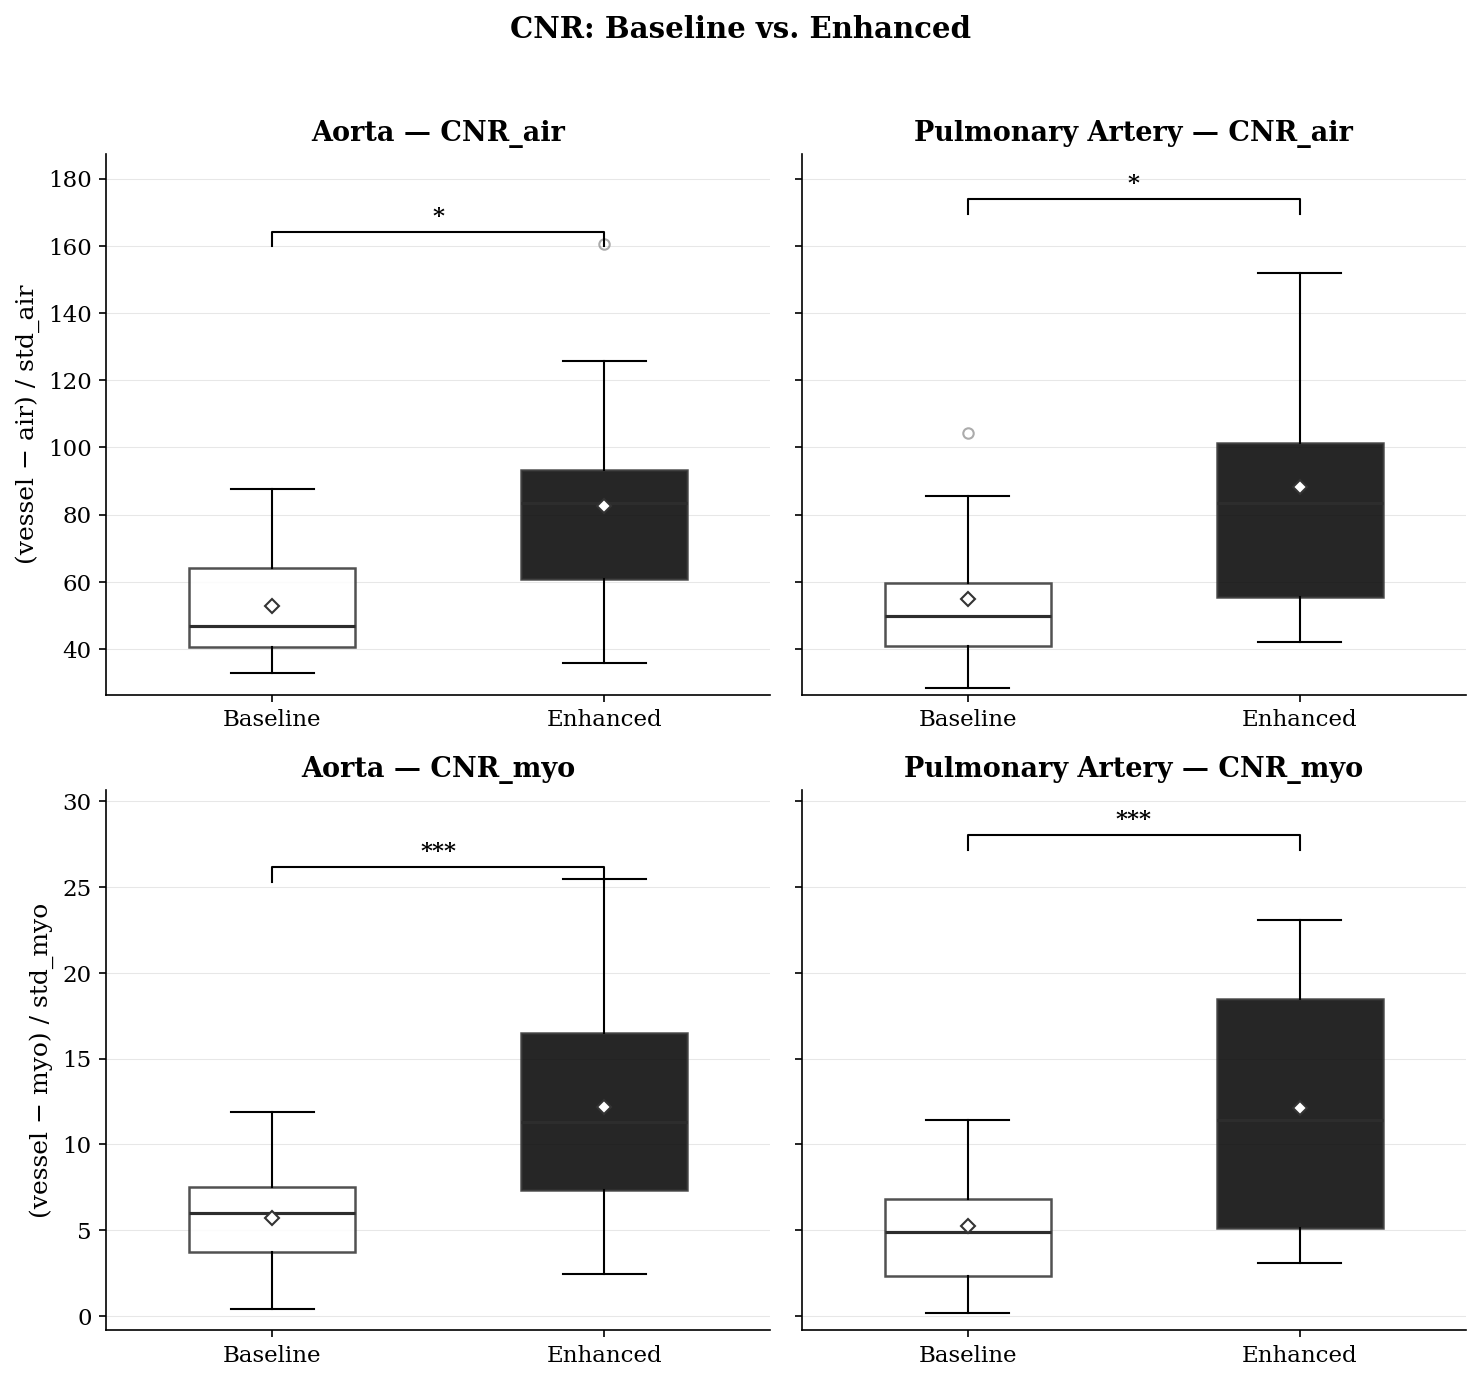

In [137]:
def _annotate_sig(ax, p, sig, x0=0, x1=1):
    """Draw a significance bracket (only if significant)."""
    if sig == "ns":
        return
    ylim = ax.get_ylim()
    y = ylim[1] - (ylim[1] - ylim[0]) * 0.02
    h = (ylim[1] - ylim[0]) * 0.03
    ax.plot([x0, x0, x1, x1], [y - h, y, y, y - h], color="black", linewidth=1.0)
    ax.text((x0 + x1) / 2, y + h * 0.3, sig, ha="center", va="bottom", fontsize=11, fontweight="bold")
    ax.set_ylim(ylim[0], y + h * 3)

fig, axes = plt.subplots(2, len(cnr_regions), figsize=(5 * len(cnr_regions), 9), sharey="row")

for j, region in enumerate(cnr_regions):
    for i, (avg_df, label) in enumerate([(cnr_air_avg, "CNR_air"), (cnr_myo_avg, "CNR_myo")]):
        ax = axes[i, j]
        subset = avg_df[avg_df["region"] == region]
        normal = subset[subset["reconstruction"] == "normal"]["cnr_mean"]
        vse = subset[subset["reconstruction"] == "vse"]["cnr_mean"]

        bp = ax.boxplot([normal, vse], positions=[0, 1], widths=0.5, **BOXPLOT_KW)
        color_boxes(bp, [COLORS["normal"], COLORS["vse"]])

        ax.set_xticks([0, 1])
        ax.set_xticklabels(["Baseline", "Enhanced"])
        ax.set_title(f"{REGION_LABELS[region]} — {label}", fontweight="bold")

        p, sig = _get_sig(label, region)
        _annotate_sig(ax, p, sig)

    axes[0, 0].set_ylabel("(vessel − air) / std_air")
    axes[1, 0].set_ylabel("(vessel − myo) / std_myo")

fig.suptitle("CNR: Baseline vs. Enhanced", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

### 1a (alt). CNR and SNR side by side

CNR_air and CNR_myo each shown with SNR for context.

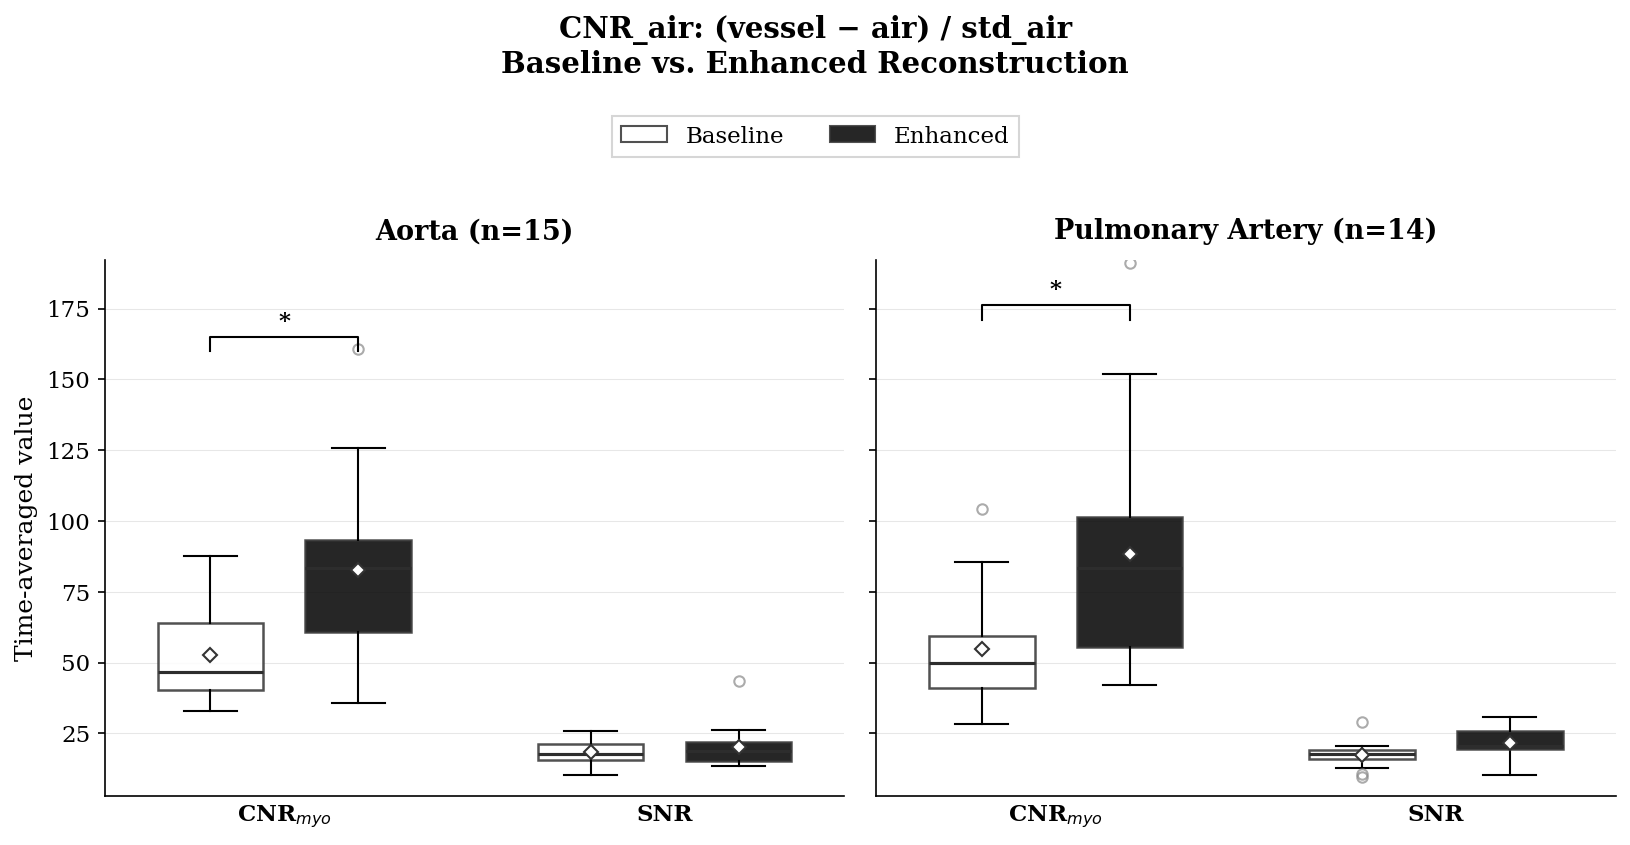

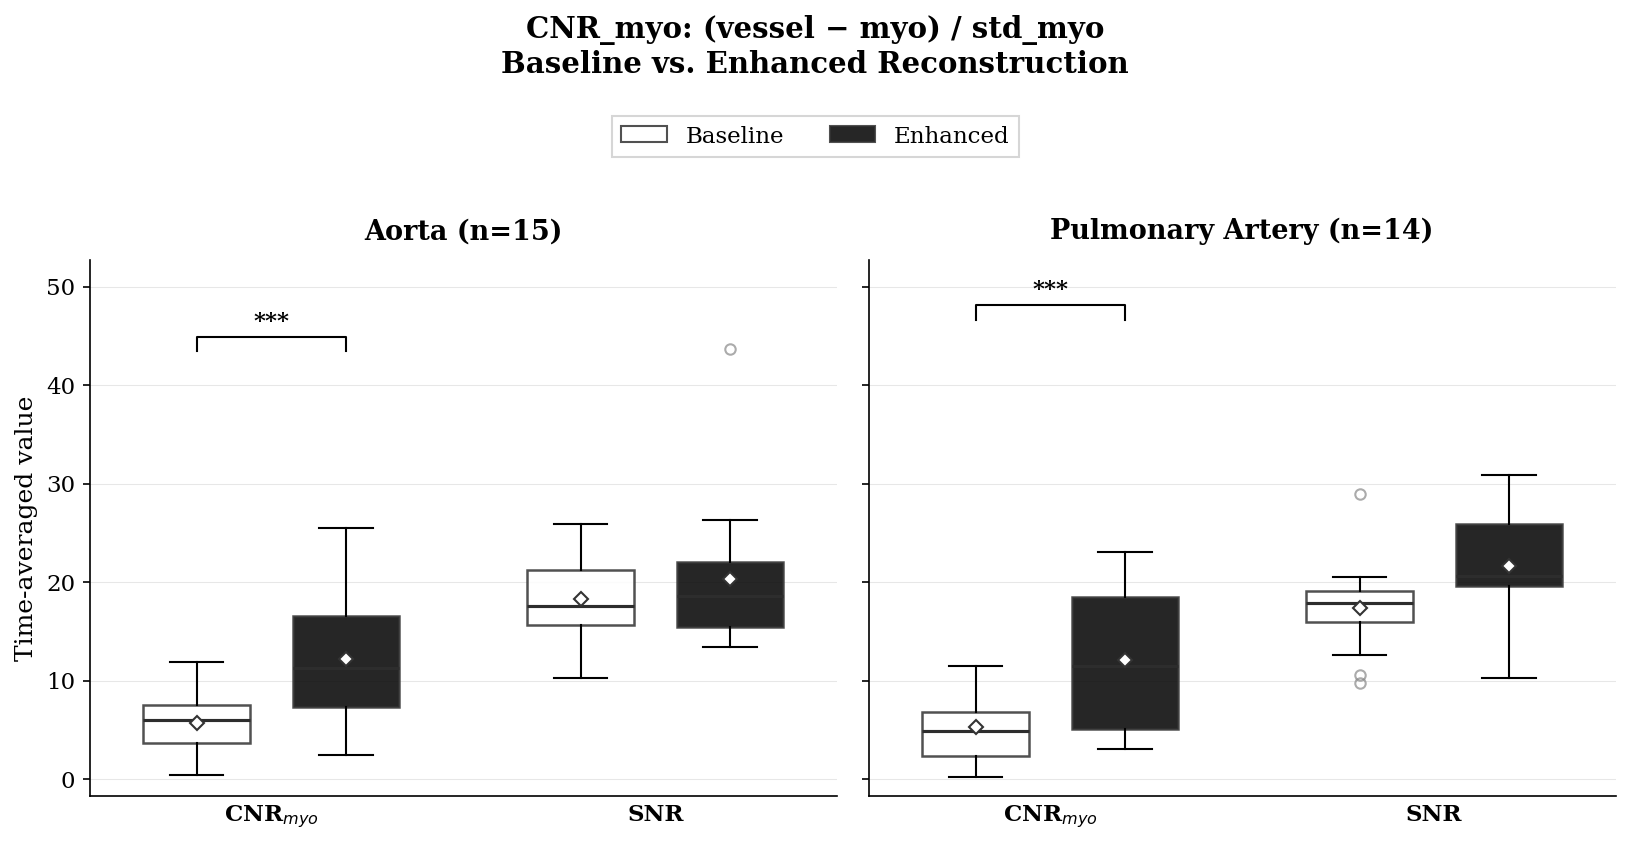

In [138]:
def _get_nv(df, region, col):
    """Return (baseline_values, enhanced_values) for a region."""
    sub = df[df["region"] == region]
    return (sub[sub["reconstruction"] == "normal"][col],
            sub[sub["reconstruction"] == "vse"][col])

for cnr_label, cnr_avg_df, metric_key in [
    ("CNR_air: (vessel − air) / std_air", cnr_air_avg, "CNR_air"),
    ("CNR_myo: (vessel − myo) / std_myo", cnr_myo_avg, "CNR_myo"),
]:
    fig, axes = plt.subplots(1, len(cnr_regions), figsize=(5.5 * len(cnr_regions), 5), sharey=True)

    for ax, region in zip(axes, cnr_regions):
        cnr_n, cnr_v = _get_nv(cnr_avg_df, region, "cnr_mean")
        snr_n, snr_v = _get_nv(snr_avg, region, "snr_mean")

        bp = ax.boxplot(
            [cnr_n, cnr_v, snr_n, snr_v],
            positions=[0, 0.7, 1.8, 2.5],
            widths=0.5,
            **BOXPLOT_KW,
        )
        color_boxes(bp, [COLORS["normal"], COLORS["vse"]] * 2)

        ax.set_xticks([0.35, 2.15])
        ax.set_xticklabels(["CNR$_{myo}$", "SNR"], fontweight="bold")
        ax.set_title(f"{REGION_LABELS[region]} (n={len(cnr_n)})", fontweight="bold", pad=10)
        ax.tick_params(axis="x", length=0)

        p, sig = _get_sig(metric_key, region)
        _annotate_sig(ax, p, sig, x0=0, x1=0.7)
        p_snr, sig_snr = _get_sig("SNR", region)
        _annotate_sig(ax, p_snr, sig_snr, x0=1.8, x1=2.5)

    axes[0].set_ylabel("Time-averaged value")
    fig.legend(handles=LEGEND_HANDLES, loc="upper center", ncol=2,
               frameon=True, fancybox=False, edgecolor="#ccc",
               fontsize=11, bbox_to_anchor=(0.5, 1.0))
    fig.suptitle(f"{cnr_label}\nBaseline vs. Enhanced Reconstruction",
                 fontsize=14, fontweight="bold", y=1.12)
    fig.tight_layout()
    plt.show()

### 1b. Paired patient-level plots: Baseline → Enhanced

Each line connects one patient's time-averaged value under Baseline (left) to Enhanced (right).
Green = improved; red = decreased. Patient labels shown for cases that decreased.

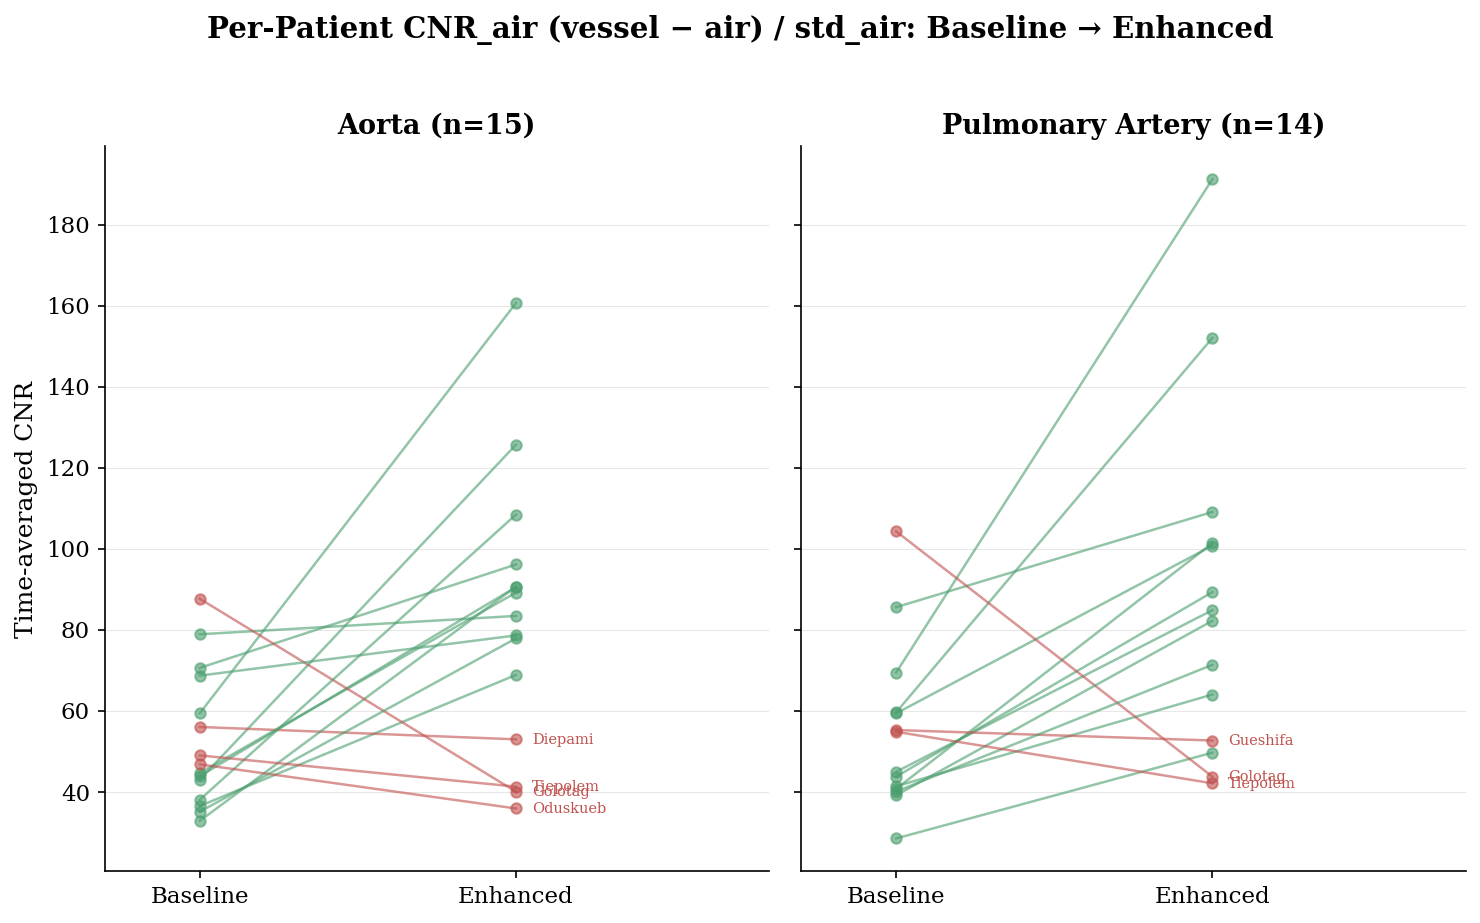

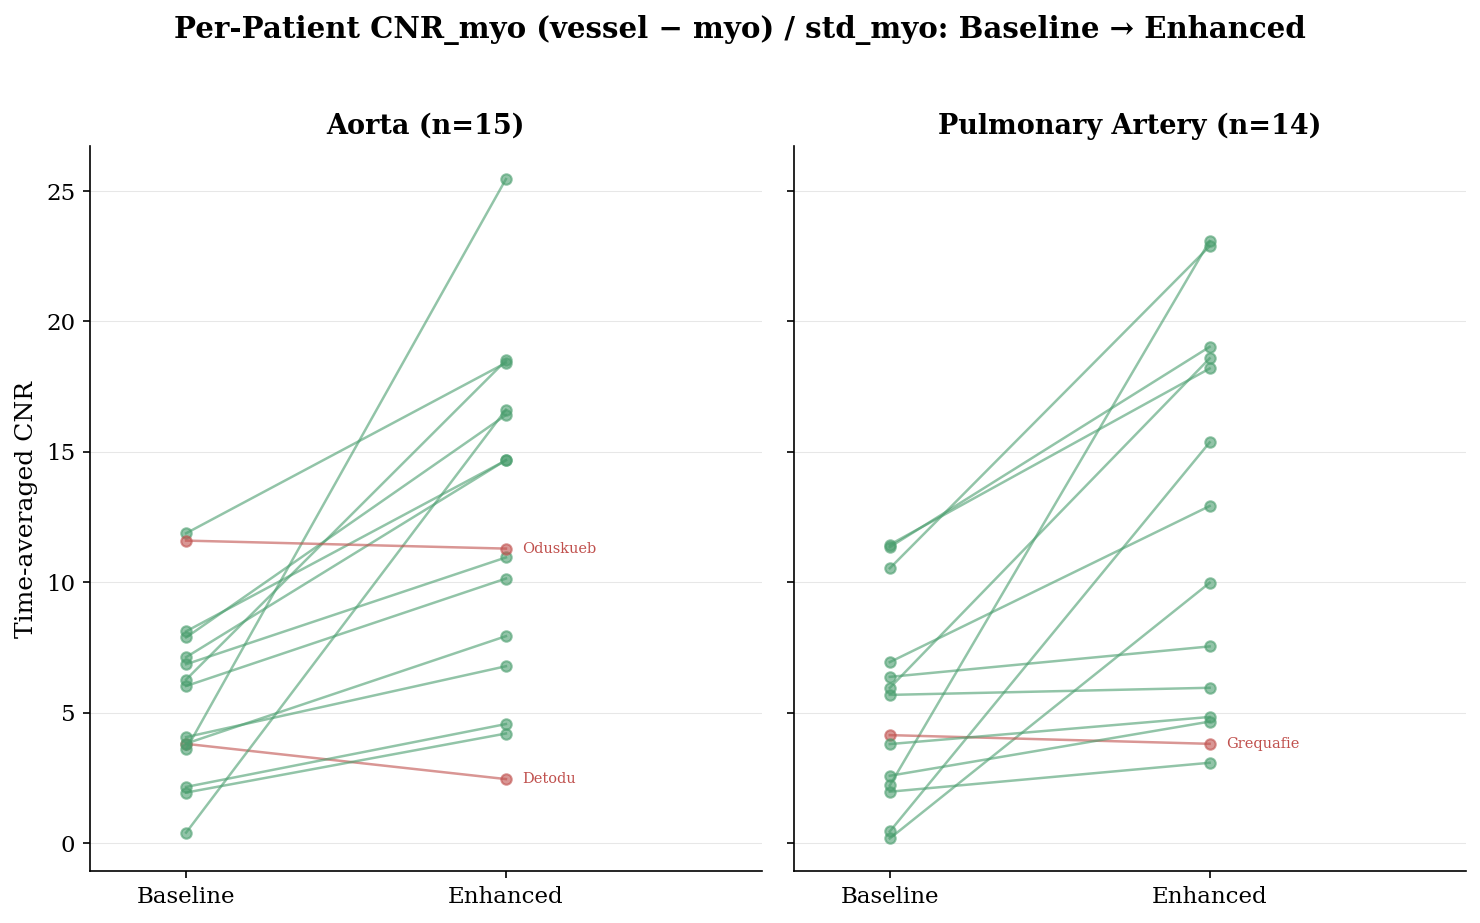

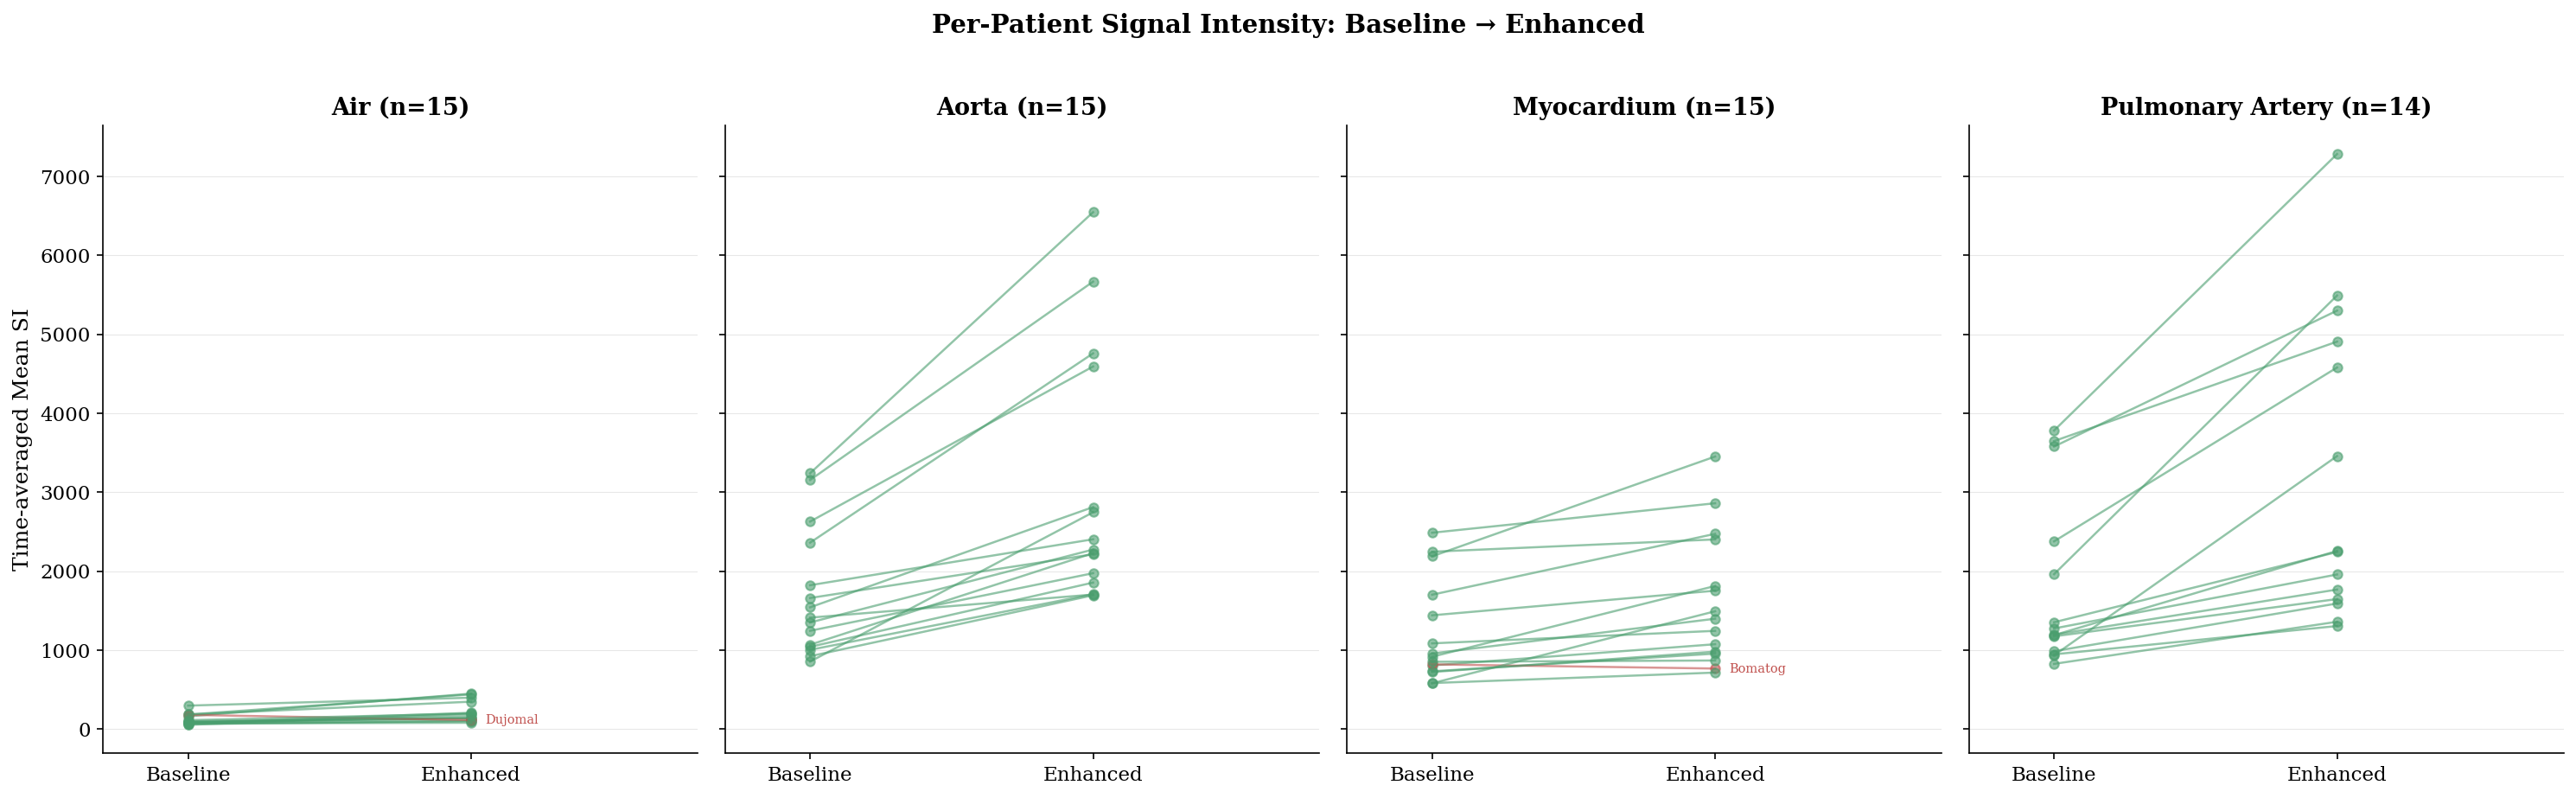

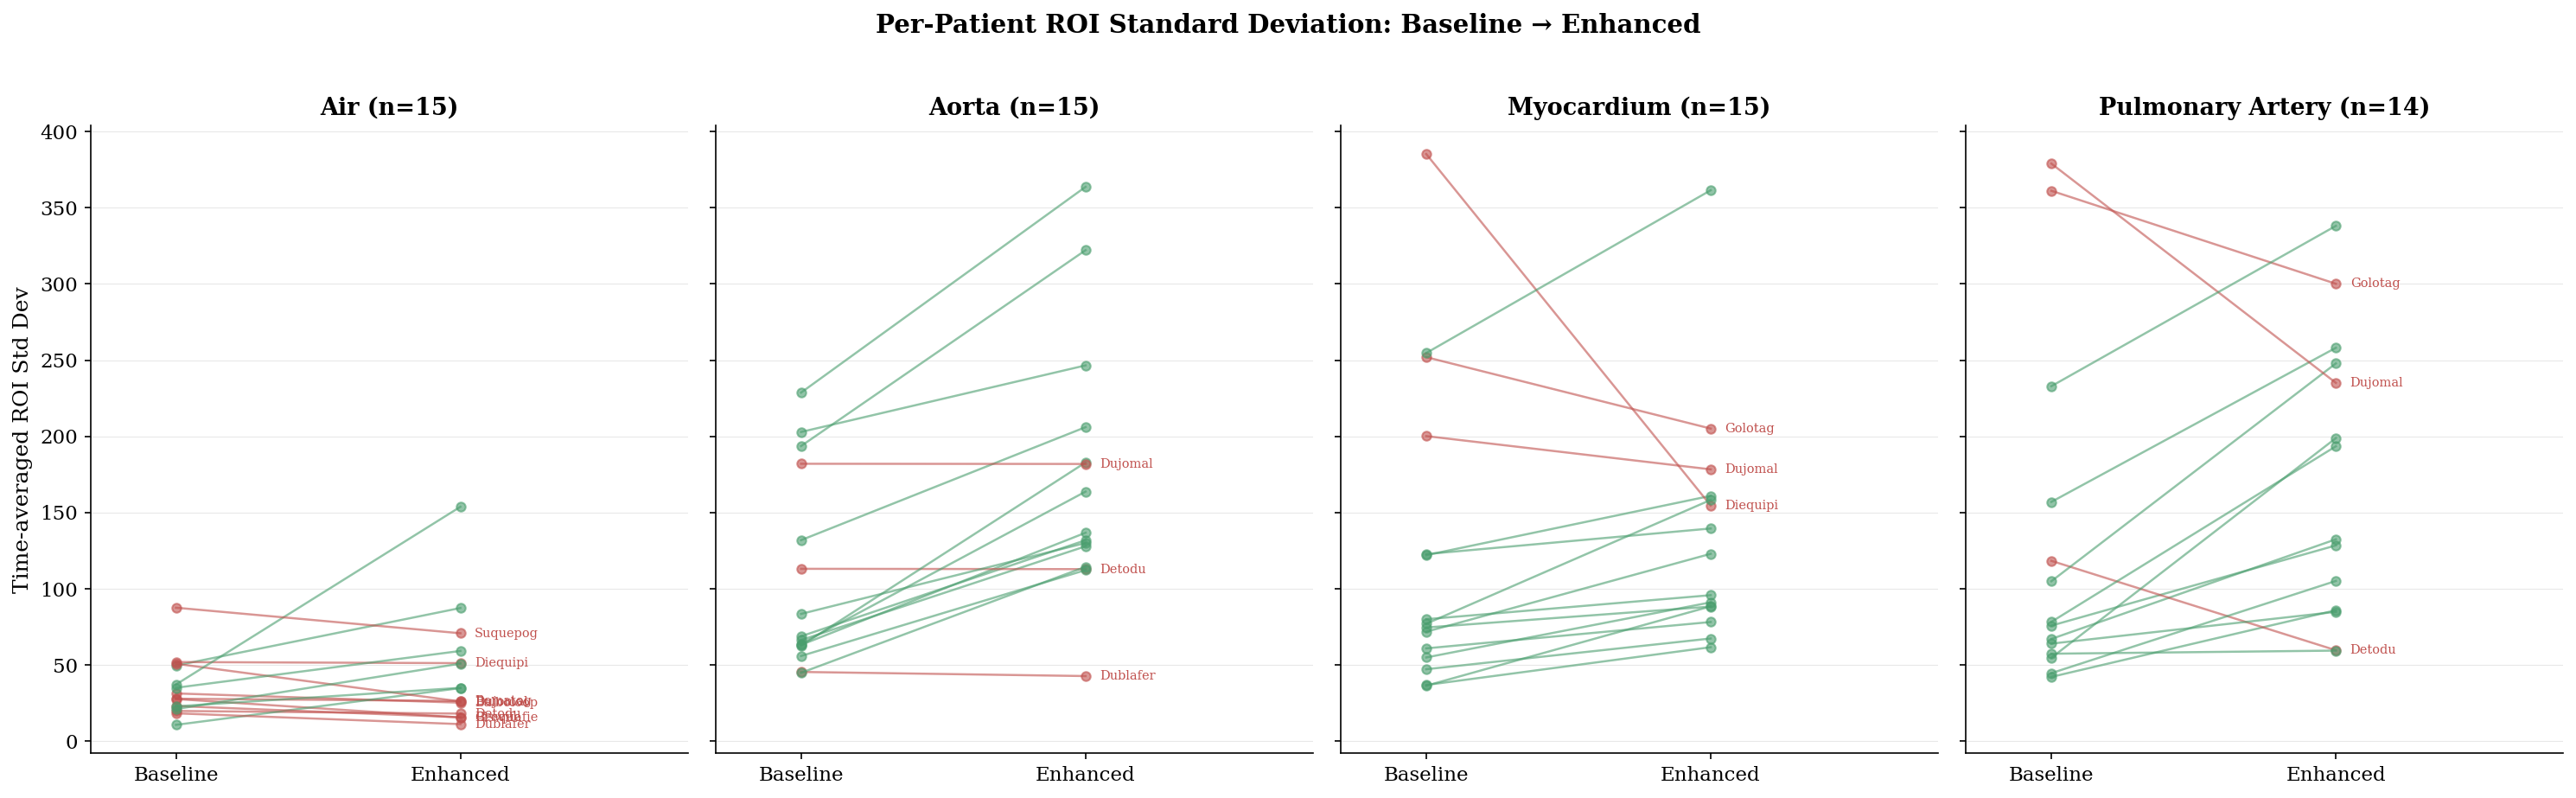

In [139]:
SLOPE_UP = "#4a9e6e"
SLOPE_DOWN = "#c0504d"

def _paired_plot(pivot_df, region_list, ylabel, title, label_col="patient"):
    """Paired slope graph with patient labels."""
    fig, axes = plt.subplots(1, len(region_list), figsize=(5 * len(region_list), 6), sharey=True)
    if len(region_list) == 1:
        axes = [axes]

    for ax, region in zip(axes, region_list):
        pdf = pivot_df.reset_index()
        sub = pdf[pdf["region"] == region].dropna(subset=["normal", "vse"])

        for _, row in sub.iterrows():
            color = SLOPE_UP if row["vse"] >= row["normal"] else SLOPE_DOWN
            ax.plot([0, 1], [row["normal"], row["vse"]], marker="o", color=color,
                    alpha=0.6, linewidth=1.2, markersize=5)
            if row["vse"] < row["normal"]:
                ax.text(1.05, row["vse"], row[label_col], fontsize=7, va="center", color=SLOPE_DOWN)

        ax.set_xticks([0, 1])
        ax.set_xticklabels([LABELS["normal"], LABELS["vse"]])
        ax.set_title(f"{REGION_LABELS[region]} (n={len(sub)})", fontweight="bold")
        ax.set_xlim(-0.3, 1.8)

    axes[0].set_ylabel(ylabel)
    fig.suptitle(title, fontsize=14, fontweight="bold", y=1.02)
    fig.tight_layout()
    plt.show()

# CNR_air paired
_paired_plot(cnr_air_pivot, cnr_regions,
             "Time-averaged CNR", "Per-Patient CNR_air (vessel − air) / std_air: Baseline → Enhanced")

# CNR_myo paired
_paired_plot(cnr_myo_pivot, cnr_regions,
             "Time-averaged CNR", "Per-Patient CNR_myo (vessel − myo) / std_myo: Baseline → Enhanced")

# SI paired (all regions, for debugging)
si_pivot = si_avg.pivot_table(index=["patient", "region"], columns="reconstruction", values="si_mean")
si_pivot["vse_minus_normal"] = si_pivot["vse"] - si_pivot["normal"]
_paired_plot(si_pivot, regions,
             "Time-averaged Mean SI", "Per-Patient Signal Intensity: Baseline → Enhanced")

# Std paired (all regions) — check whether enhancement changes within-ROI variability
std_avg = (
    data.groupby(["patient", "region", "reconstruction"])["std"]
    .mean()
    .reset_index()
    .rename(columns={"std": "std_mean"})
)
std_pivot = std_avg.pivot_table(index=["patient", "region"], columns="reconstruction", values="std_mean")
std_pivot["vse_minus_normal"] = std_pivot["vse"] - std_pivot["normal"]
_paired_plot(std_pivot, regions,
             "Time-averaged ROI Std Dev", "Per-Patient ROI Standard Deviation: Baseline → Enhanced")

In [140]:
# Paired statistical tests for SI and Std changes (Ao, IVS, PA)
test_regions = ["Ao", "IVS", "PA"]

si_stats = _paired_stats(si_pivot, "Mean SI", region_list=test_regions)
std_stats = _paired_stats(std_pivot, "Std Dev", region_list=test_regions)

si_std_stats = pd.concat([si_stats, std_stats], ignore_index=True)
si_std_stats["wilcoxon_sig"] = si_std_stats["wilcoxon_p"].apply(_sig)
si_std_stats["ttest_sig"] = si_std_stats["ttest_p"].apply(_sig)
si_std_stats["normality"] = si_std_stats["shapiro_p"].apply(lambda p: "yes" if p > 0.05 else "no")

display_cols = ["metric", "region", "n", "normal_mean", "vse_mean", "diff_mean", "diff_std",
                "normality", "wilcoxon_p", "wilcoxon_sig", "ttest_p", "ttest_sig", "cohens_d"]
display(si_std_stats[display_cols].round(4))

,metric,region,n,normal_mean,vse_mean,diff_mean,diff_std,normality,wilcoxon_p,wilcoxon_sig,ttest_p,ttest_sig,cohens_d
0,Mean SI,Ao,15,1686.7304,3011.8130,1325.0826,853.5510,yes,0.0001,***,0.0000,***,1.5524
1,Mean SI,IVS,15,1207.3698,1616.0100,408.6402,366.1398,yes,0.0002,***,0.0009,***,1.1161
2,Mean SI,PA,14,1801.4590,3224.5726,1423.1136,1064.9982,no,0.0001,***,0.0003,***,1.3363
3,Std Dev,Ao,15,107.0053,171.6464,64.6411,42.7279,yes,0.0009,***,0.0001,***,1.5129
4,Std Dev,IVS,15,125.0065,136.7184,11.7120,73.9888,no,0.1070,ns,0.5631,ns,0.1583
5,Std Dev,PA,14,131.1415,173.3214,42.1799,81.0223,yes,0.0906,ns,0.0831,ns,0.5206


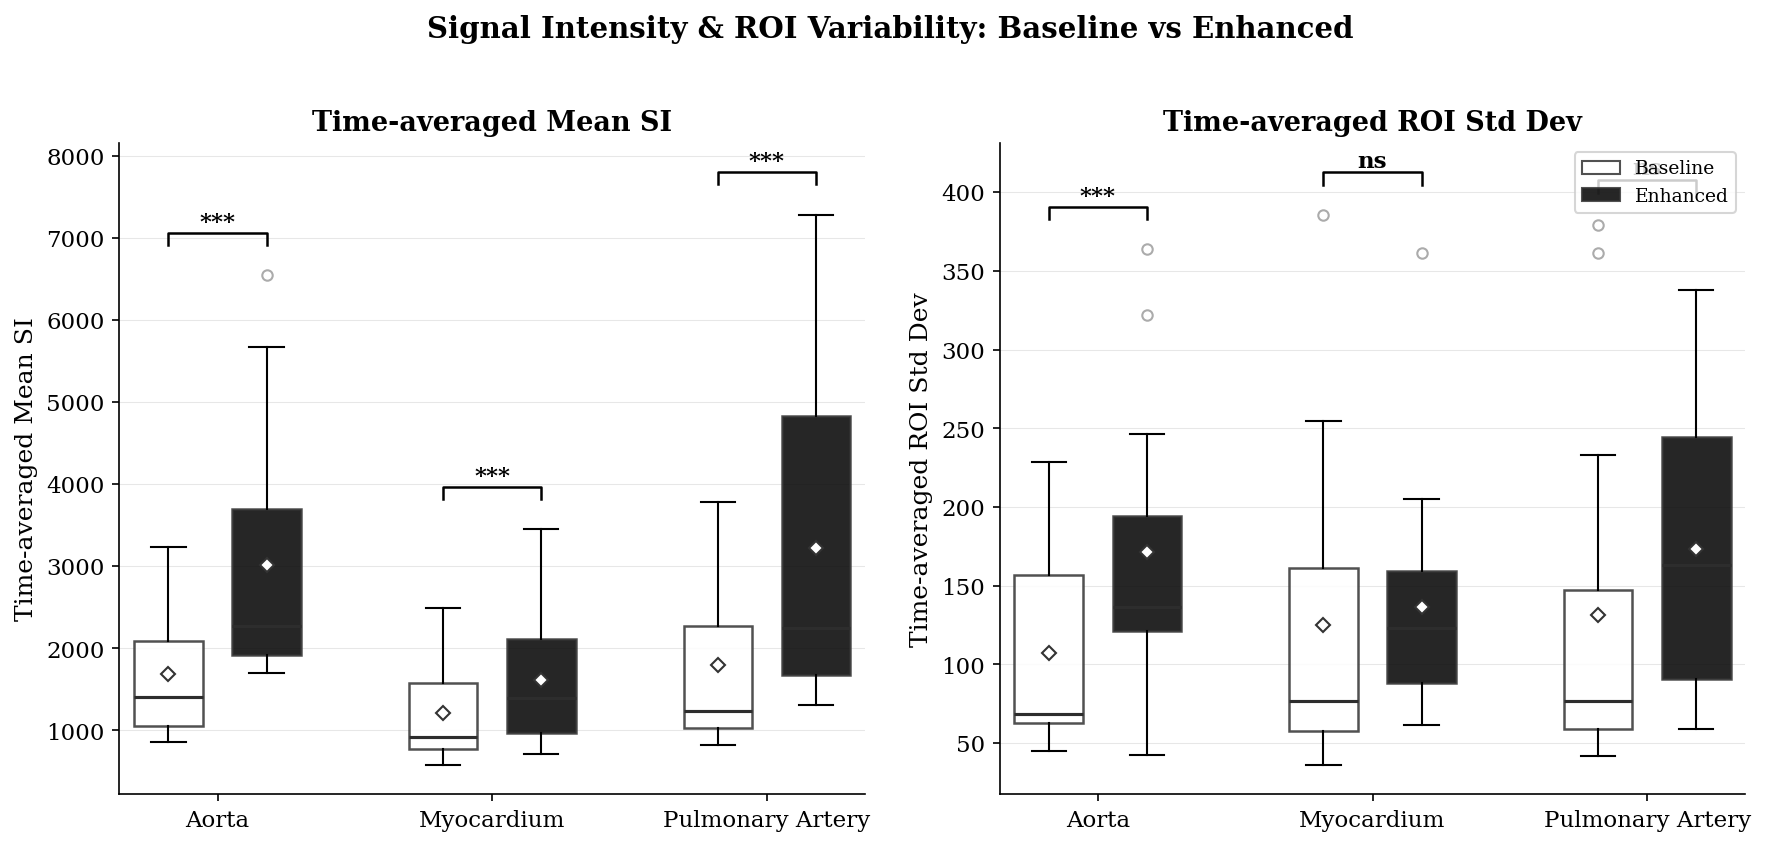

In [141]:
# Paired boxplots of Mean SI and Std Dev (Baseline vs Enhanced) with significance brackets
test_regions = ["Ao", "IVS", "PA"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), sharey=False)

for ax, (metric_label, avg_df, val_col, stats_df_metric) in zip(axes, [
    ("Time-averaged Mean SI", si_avg, "si_mean", "Mean SI"),
    ("Time-averaged ROI Std Dev", std_avg, "std_mean", "Std Dev"),
]):
    positions = []
    box_data = []
    colors_list = []
    tick_positions = []
    tick_labels = []

    offset = 0
    for region in test_regions:
        for recon, color in [("normal", COLORS["normal"]), ("vse", COLORS["vse"])]:
            sub = avg_df[(avg_df["region"] == region) & (avg_df["reconstruction"] == recon)]
            box_data.append(sub[val_col].values)
            colors_list.append(color)
            positions.append(offset)
            offset += 1
        tick_positions.append(offset - 1.5)
        tick_labels.append(REGION_LABELS[region])
        offset += 0.8

    bp = ax.boxplot(box_data, positions=positions, widths=0.7, **BOXPLOT_KW)
    color_boxes(bp, colors_list)

    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels)
    ax.set_ylabel(metric_label)
    ax.set_title(metric_label, fontweight="bold", fontsize=13)

    # Add significance brackets
    for i, region in enumerate(test_regions):
        row = si_std_stats[(si_std_stats["metric"] == stats_df_metric) & (si_std_stats["region"] == region)]
        sig = row["wilcoxon_sig"].values[0]
        x0 = i * 2.8
        x1 = x0 + 1
        y_vals = np.concatenate([box_data[i * 2], box_data[i * 2 + 1]])
        y_max = y_vals.max()
        y_bracket = y_max + (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.05
        bracket_h = (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.02

        ax.plot([x0, x0, x1, x1], [y_bracket, y_bracket + bracket_h, y_bracket + bracket_h, y_bracket],
                color="black", linewidth=1.2)
        ax.text((x0 + x1) / 2, y_bracket + bracket_h, sig,
                ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.legend(handles=LEGEND_HANDLES, loc="upper right", fontsize=9)

fig.suptitle("Signal Intensity & ROI Variability: Baseline vs Enhanced",
             fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

### 1b½. CNR_myo decomposition: numerator vs denominator

For each patient, decompose the CNR_myo change into how much came from
the numerator (mean_vessel − mean_IVS) changing vs the denominator (std_IVS) changing.

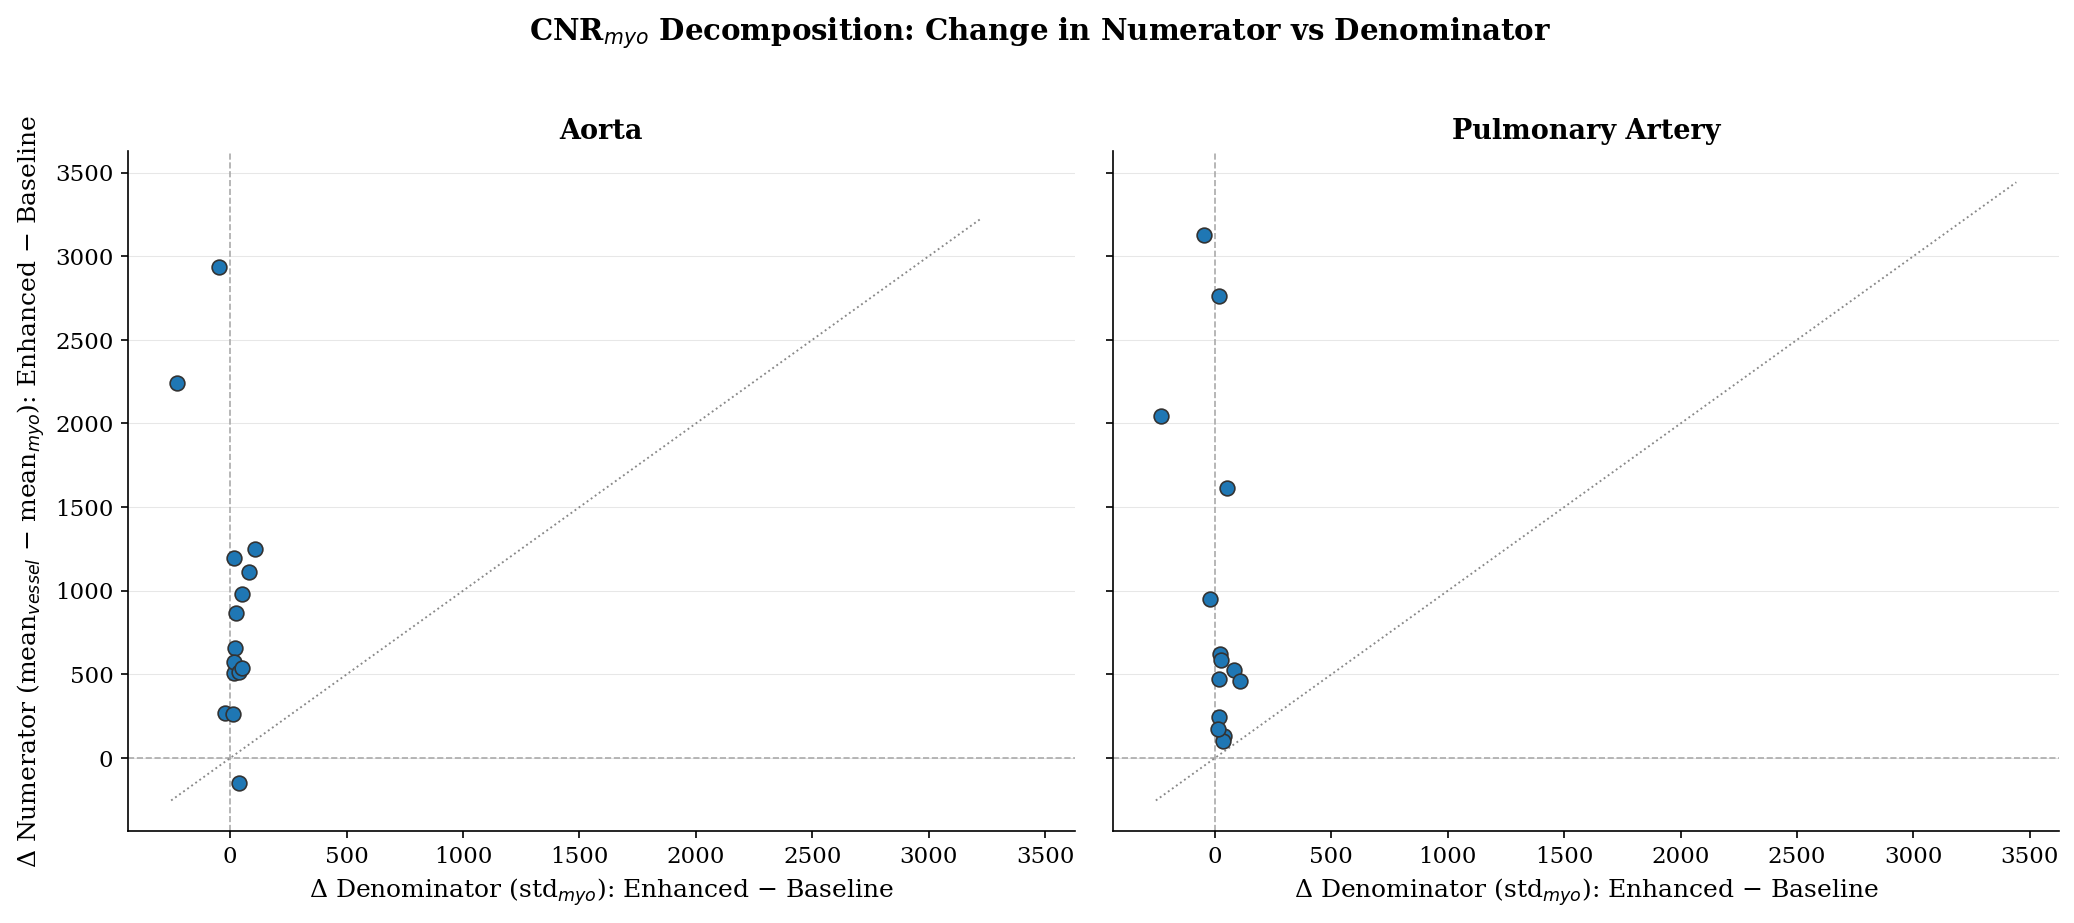

In [142]:
# Per-patient CNR_myo decomposition: scatter of numerator change vs denominator change
# numerator = mean_vessel - mean_IVS,  denominator = std_IVS
# Upper-right: numerator ↑, denominator ↑  |  Upper-left: numerator ↑, denominator ↓

decomp_rows = []
for region in cnr_regions:
    for patient in sorted(data["patient"].unique()):
        vals = {}
        for recon in ["normal", "vse"]:
            vessel_sub = data[(data["patient"] == patient) & (data["region"] == region) & (data["reconstruction"] == recon)]
            ivs_sub = data[(data["patient"] == patient) & (data["region"] == "IVS") & (data["reconstruction"] == recon)]
            if vessel_sub.empty or ivs_sub.empty:
                continue
            vals[recon] = {
                "numerator": vessel_sub["mean"].mean() - ivs_sub["mean"].mean(),
                "denominator": ivs_sub["std"].mean(),
            }
        if "normal" in vals and "vse" in vals:
            decomp_rows.append({
                "patient": patient, "region": region,
                "delta_num": vals["vse"]["numerator"] - vals["normal"]["numerator"],
                "delta_den": vals["vse"]["denominator"] - vals["normal"]["denominator"],
            })

decomp = pd.DataFrame(decomp_rows)

fig, axes = plt.subplots(1, len(cnr_regions), figsize=(7 * len(cnr_regions), 6), sharey=True, sharex=True)
if len(cnr_regions) == 1:
    axes = [axes]

for ax, region in zip(axes, cnr_regions):
    sub = decomp[decomp["region"] == region]
    ax.scatter(sub["delta_den"], sub["delta_num"], s=50, color="#1f77b4",
               edgecolors="#333", linewidth=0.8, zorder=3)

    ax.axhline(0, color="#aaa", linewidth=0.8, linestyle="--")
    ax.axvline(0, color="#aaa", linewidth=0.8, linestyle="--")

    id_lo = min(sub["delta_den"].min(), sub["delta_num"].min()) * 1.1
    id_hi = max(sub["delta_den"].max(), sub["delta_num"].max()) * 1.1
    ax.plot([id_lo, id_hi], [id_lo, id_hi], color="#888", linewidth=0.9,
            linestyle=":", zorder=2, label="y = x")

    ax.set_xlabel("Δ Denominator (std$_{myo}$): Enhanced − Baseline")
    ax.set_title(f"{REGION_LABELS[region]}", fontweight="bold")

axes[0].set_ylabel("Δ Numerator (mean$_{vessel}$ − mean$_{myo}$): Enhanced − Baseline")

fig.suptitle("CNR$_{myo}$ Decomposition: Change in Numerator vs Denominator",
             fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

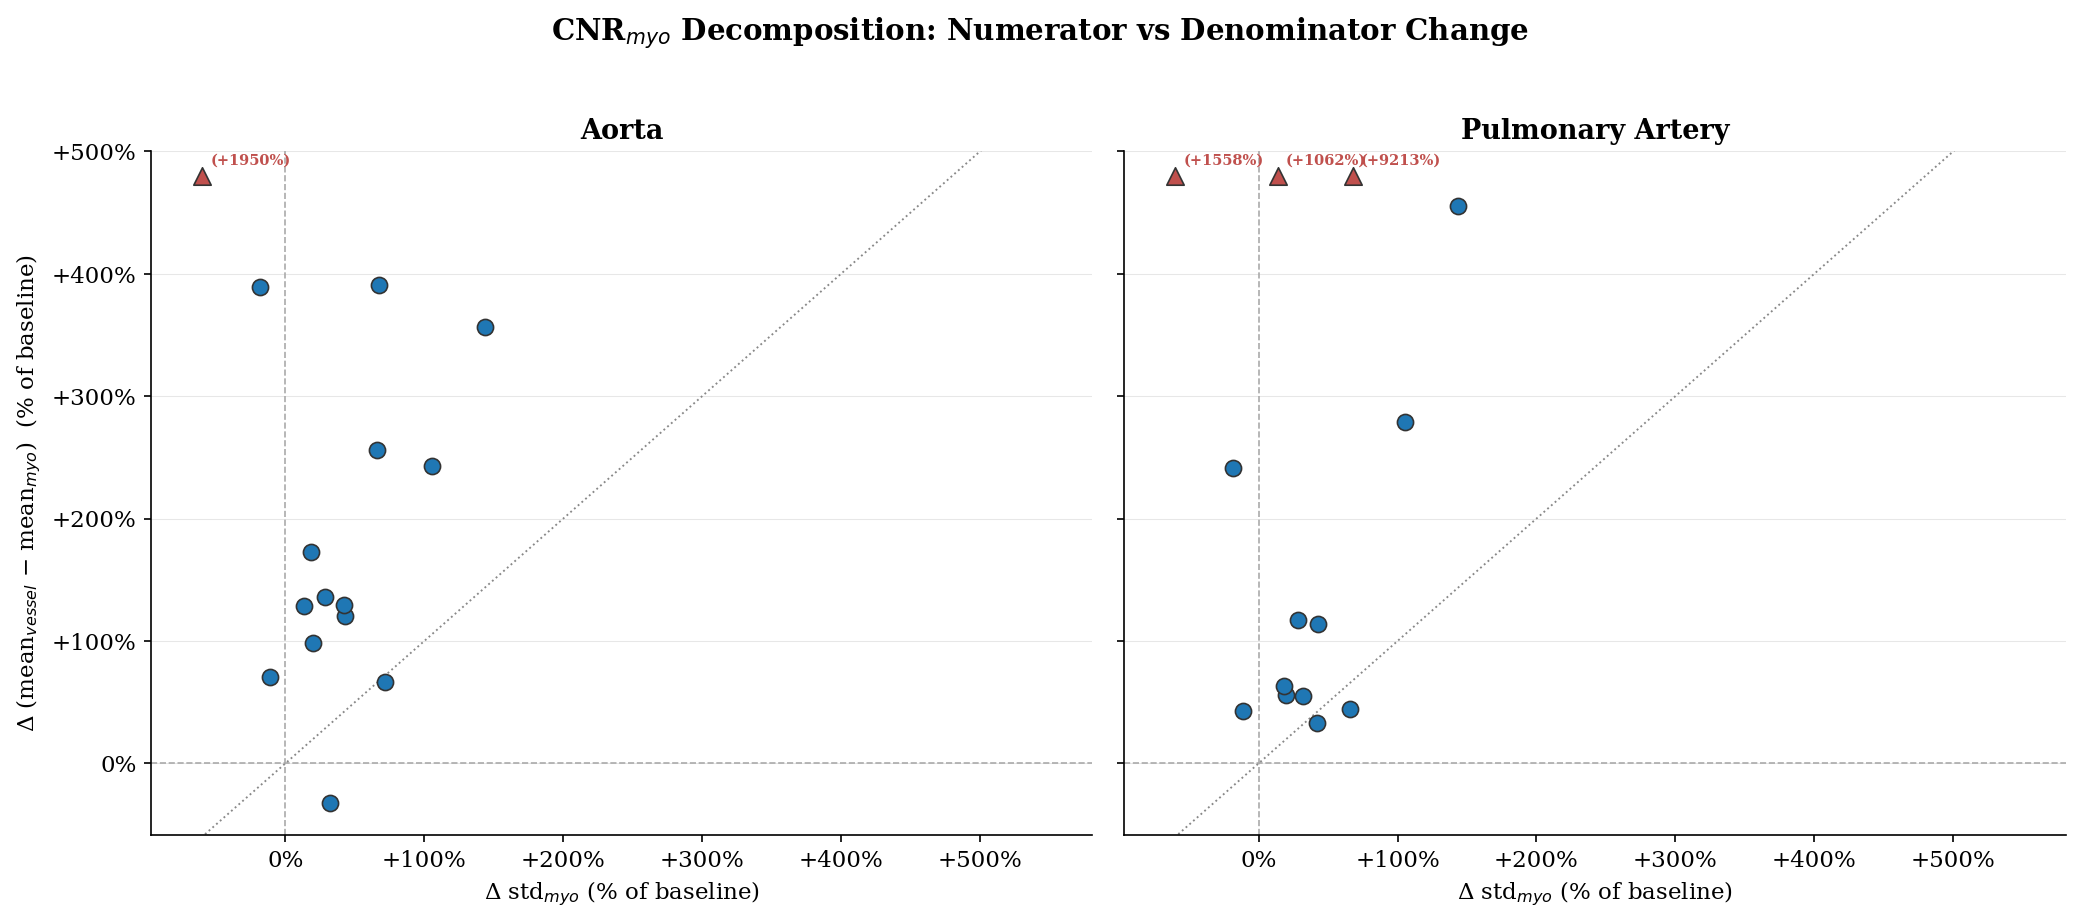

In [143]:
# Normalized decomposition scatter, clipped y-axis with outlier annotations
decomp_norm_rows = []
for region in cnr_regions:
    for patient in sorted(data["patient"].unique()):
        vals = {}
        for recon in ["normal", "vse"]:
            vessel_sub = data[(data["patient"] == patient) & (data["region"] == region) & (data["reconstruction"] == recon)]
            ivs_sub = data[(data["patient"] == patient) & (data["region"] == "IVS") & (data["reconstruction"] == recon)]
            if vessel_sub.empty or ivs_sub.empty:
                continue
            vals[recon] = {
                "numerator": vessel_sub["mean"].mean() - ivs_sub["mean"].mean(),
                "denominator": ivs_sub["std"].mean(),
            }
        if "normal" in vals and "vse" in vals:
            num_bl, den_bl = vals["normal"]["numerator"], vals["normal"]["denominator"]
            num_en, den_en = vals["vse"]["numerator"], vals["vse"]["denominator"]
            decomp_norm_rows.append({
                "patient": patient, "region": region,
                "frac_num": (num_en - num_bl) / abs(num_bl) if num_bl != 0 else np.nan,
                "frac_den": (den_en - den_bl) / abs(den_bl) if den_bl != 0 else np.nan,
            })

decomp_norm = pd.DataFrame(decomp_norm_rows).dropna()

Y_CLIP = 5

fig, axes = plt.subplots(1, len(cnr_regions), figsize=(7 * len(cnr_regions), 6), sharey=True, sharex=True)
if len(cnr_regions) == 1:
    axes = [axes]

for ax, region in zip(axes, cnr_regions):
    sub = decomp_norm[decomp_norm["region"] == region]
    inliers = sub[sub["frac_num"] <= Y_CLIP]
    outliers = sub[sub["frac_num"] > Y_CLIP]

    ax.scatter(inliers["frac_den"], inliers["frac_num"], s=60, color="#1f77b4",
               edgecolors="#333", linewidth=0.8, zorder=3)

    for _, row in outliers.iterrows():
        ax.scatter(row["frac_den"], Y_CLIP * 0.96, s=70, color="#c0504d",
                   edgecolors="#333", linewidth=0.8, zorder=3, marker="^")
        ax.annotate(f"(+{row['frac_num']:.0%})",
                     (row["frac_den"], Y_CLIP * 0.96),
                     fontsize=7, ha="left", va="bottom", xytext=(4, 4),
                     textcoords="offset points", color="#c0504d", fontweight="bold")

    ax.axhline(0, color="#aaa", linewidth=0.8, linestyle="--")
    ax.axvline(0, color="#aaa", linewidth=0.8, linestyle="--")
    ax.set_ylim(None, Y_CLIP)

    id_lo = min(sub["frac_den"].min(), -0.5) * 1.1
    id_hi = max(sub["frac_den"].max(), Y_CLIP) * 1.1
    ax.plot([id_lo, id_hi], [id_lo, id_hi], color="#888", linewidth=0.9,
            linestyle=":", zorder=2, label="y = x")

    from matplotlib.ticker import FuncFormatter
    pct_fmt = FuncFormatter(lambda x, _: f"{x:+.0%}" if x != 0 else "0%")
    ax.xaxis.set_major_formatter(pct_fmt)
    ax.yaxis.set_major_formatter(pct_fmt)

    ax.set_xlabel("Δ std$_{myo}$ (% of baseline)", fontsize=11)
    ax.set_title(f"{REGION_LABELS[region]}", fontweight="bold", fontsize=13)

axes[0].set_ylabel("Δ (mean$_{vessel}$ − mean$_{myo}$)  (% of baseline)", fontsize=11)

fig.suptitle("CNR$_{myo}$ Decomposition: Numerator vs Denominator Change",
             fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

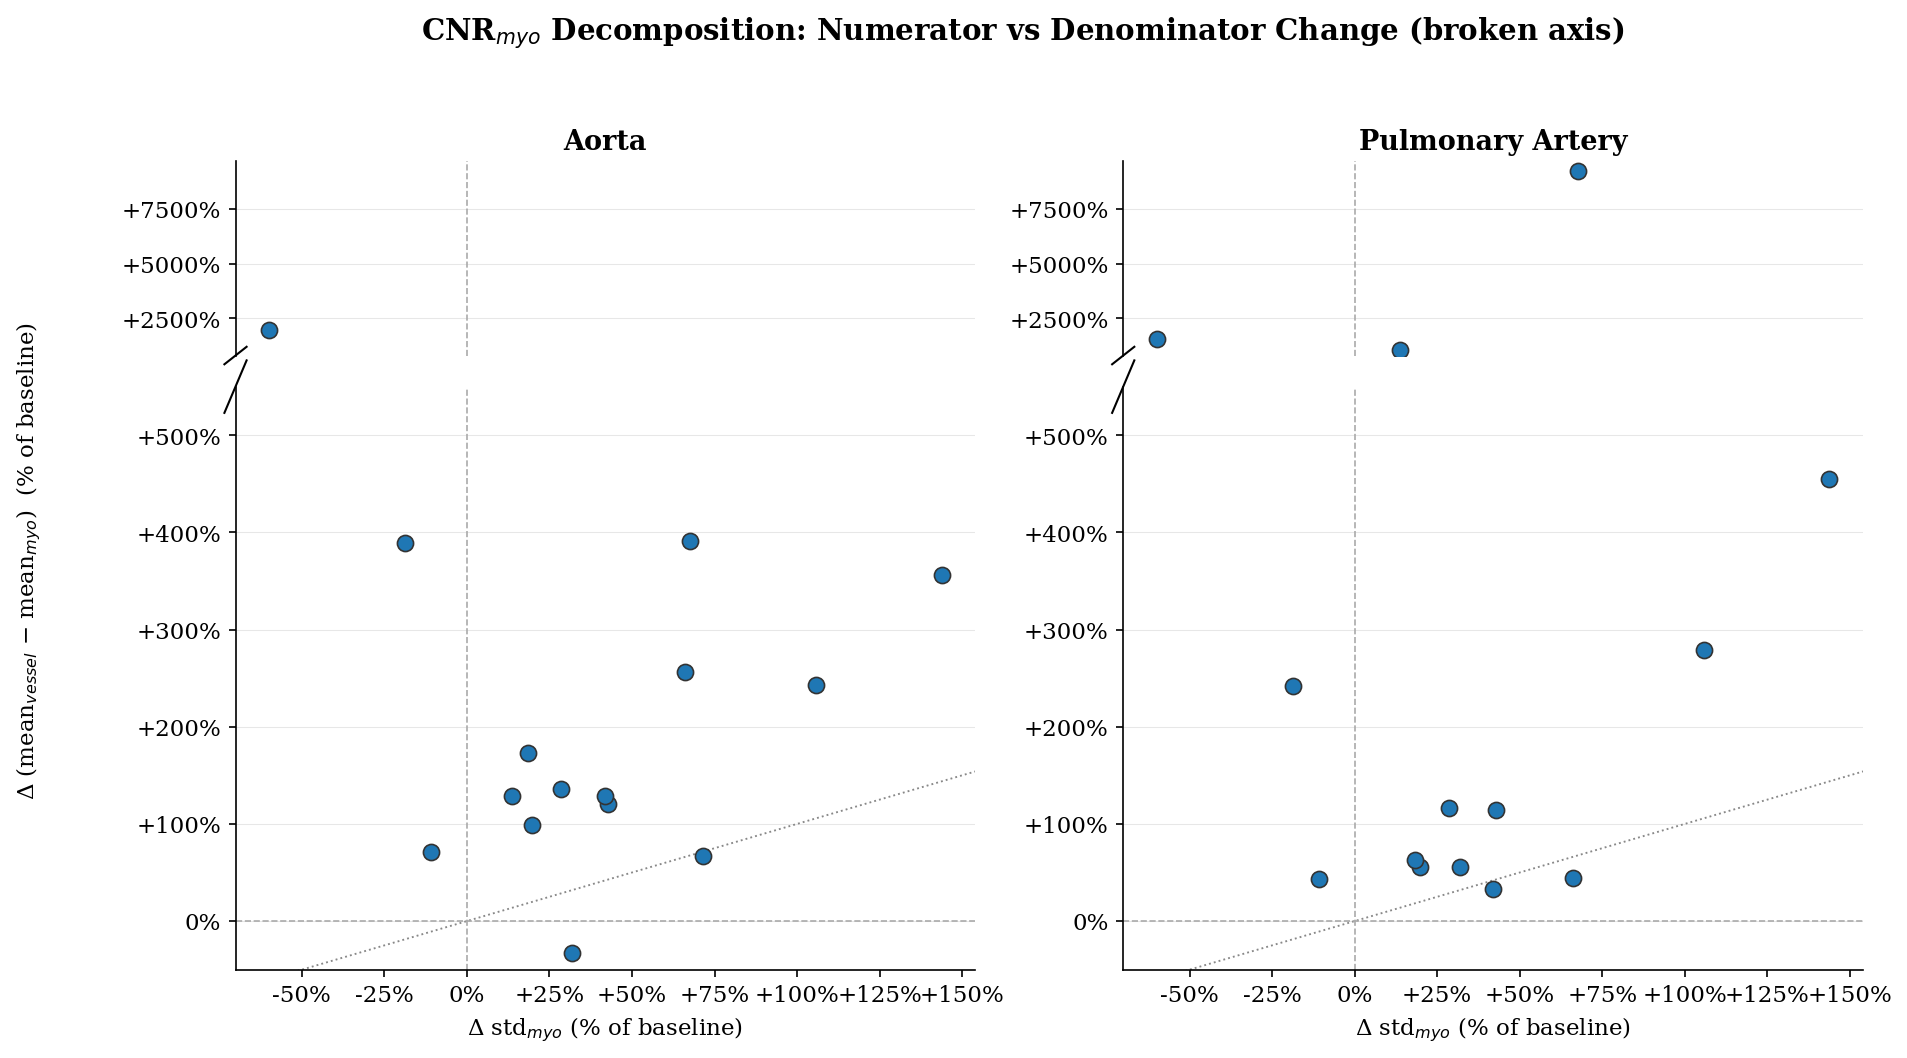

In [144]:
# Broken-axis version of the normalized decomposition scatter
from matplotlib.ticker import FuncFormatter

Y_BREAK_LO = 5.5   # top of the lower panel
Y_BREAK_HI = 8     # bottom of the upper panel
HEIGHT_RATIO = [1, 3]  # upper : lower

pct_fmt = FuncFormatter(lambda x, _: f"{x:+.0%}" if x != 0 else "0%")

# Shared limits across Ao and PA for direct comparison
x_ptp = np.ptp(decomp_norm["frac_den"].values)
x_pad = 0.05 * x_ptp if x_ptp > 0 else 0.1
x_lim_shared = (decomp_norm["frac_den"].min() - x_pad, decomp_norm["frac_den"].max() + x_pad)
y_top_max = decomp_norm["frac_num"].max() * 1.05

fig, all_axes = plt.subplots(2, len(cnr_regions),
                              figsize=(7 * len(cnr_regions), 7),
                              sharex="col",
                              gridspec_kw={"height_ratios": HEIGHT_RATIO, "hspace": 0.08})

for col, region in enumerate(cnr_regions):
    ax_top = all_axes[0, col]
    ax_bot = all_axes[1, col]
    sub = decomp_norm[decomp_norm["region"] == region]

    sub_bot = sub[sub["frac_num"] <= Y_BREAK_LO]
    sub_top = sub[sub["frac_num"] >= Y_BREAK_HI]

    ax_bot.scatter(sub_bot["frac_den"], sub_bot["frac_num"], s=60, color="#1f77b4",
                   edgecolors="#333", linewidth=0.8, zorder=3)
    ax_top.scatter(sub_top["frac_den"], sub_top["frac_num"], s=60, color="#1f77b4",
                   edgecolors="#333", linewidth=0.8, zorder=3)

    id_lo = min(x_lim_shared[0], -0.5)
    id_hi = max(x_lim_shared[1], y_top_max)
    for ax in (ax_top, ax_bot):
        ax.plot([id_lo, id_hi], [id_lo, id_hi], color="#888", linewidth=0.9,
                linestyle=":", zorder=2)
        ax.axhline(0, color="#aaa", linewidth=0.8, linestyle="--")
        ax.axvline(0, color="#aaa", linewidth=0.8, linestyle="--")
        ax.xaxis.set_major_formatter(pct_fmt)
        ax.yaxis.set_major_formatter(pct_fmt)

    ax_bot.set_ylim(-0.5, Y_BREAK_LO)
    ax_top.set_ylim(Y_BREAK_HI, y_top_max)
    for ax in (ax_top, ax_bot):
        ax.set_xlim(x_lim_shared)

    # Hide spines at the break
    ax_top.spines["bottom"].set_visible(False)
    ax_bot.spines["top"].set_visible(False)
    ax_top.tick_params(bottom=False, labelbottom=False)

    # Draw break marks on the left spine only
    d = 0.015
    bkw = dict(color="black", clip_on=False, linewidth=1, zorder=10)
    ax_top.plot([-d, +d], [-d*3, +d*3], transform=ax_top.transAxes, **bkw)
    ax_bot.plot([-d, +d], [1 - d*3, 1 + d*3], transform=ax_bot.transAxes, **bkw)

    ax_bot.set_xlabel("Δ std$_{myo}$ (% of baseline)", fontsize=11)
    ax_top.set_title(f"{REGION_LABELS[region]}", fontweight="bold", fontsize=13)

# Shared y-label
fig.text(0.02, 0.5, "Δ (mean$_{vessel}$ − mean$_{myo}$)  (% of baseline)",
         va="center", rotation="vertical", fontsize=11)

fig.suptitle("CNR$_{myo}$ Decomposition: Numerator vs Denominator Change (broken axis)",
             fontsize=14, fontweight="bold", y=1.02)
plt.show()

### 1b¾. Per-patient detail: SI and Std across all regions

5×3 grid (one subplot per patient). Each subplot shows paired Baseline→Enhanced
values for mean SI and std, across all four ROI regions.

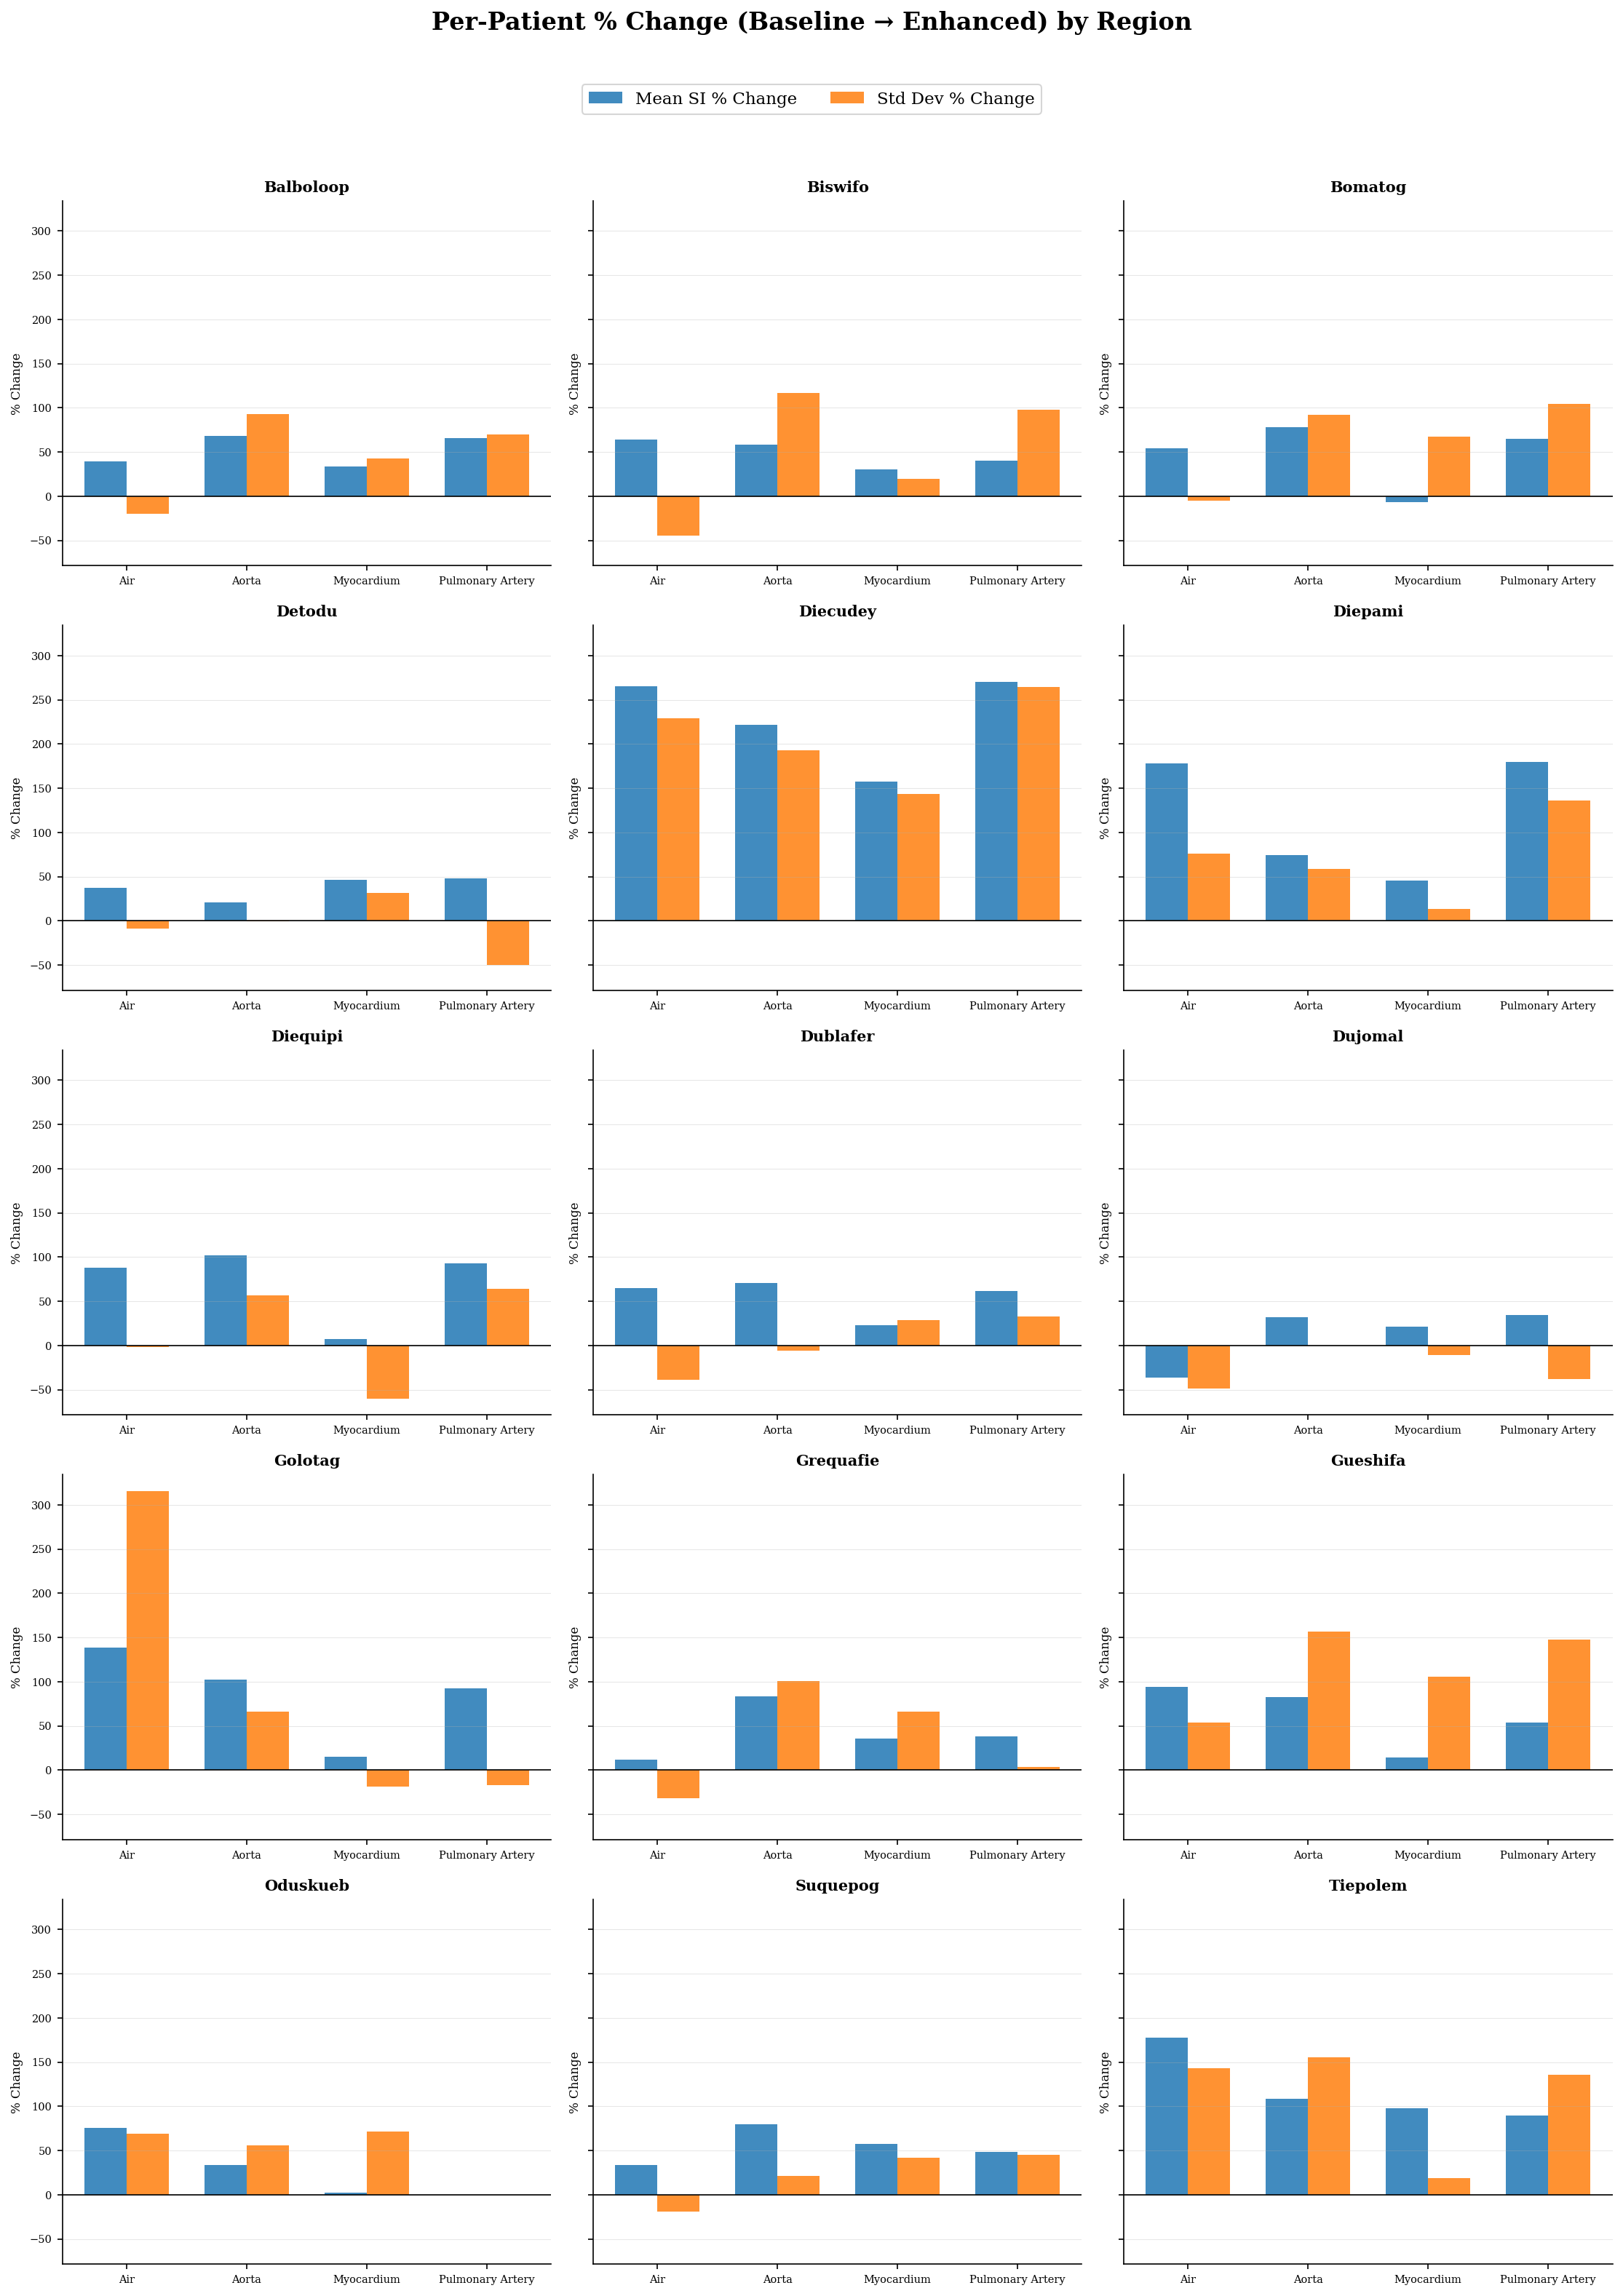

In [145]:
patients = sorted(data["patient"].unique())
n_patients = len(patients)
n_cols, n_rows = 3, 5

SI_COLOR = "#1f77b4"
STD_COLOR = "#ff7f0e"

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), squeeze=False, sharey=True)

for idx, patient in enumerate(patients):
    row_i, col_i = divmod(idx, n_cols)
    ax = axes[row_i][col_i]

    pt_data = data[data["patient"] == patient]

    x = np.arange(len(regions))
    w = 0.35

    si_pct, std_pct = [], []
    for region in regions:
        bl = pt_data[(pt_data["region"] == region) & (pt_data["reconstruction"] == "normal")]
        en = pt_data[(pt_data["region"] == region) & (pt_data["reconstruction"] == "vse")]
        if bl.empty or en.empty:
            si_pct.append(0)
            std_pct.append(0)
            continue
        bl_si, en_si = bl["mean"].mean(), en["mean"].mean()
        bl_std, en_std = bl["std"].mean(), en["std"].mean()
        si_pct.append((en_si - bl_si) / bl_si * 100 if bl_si != 0 else 0)
        std_pct.append((en_std - bl_std) / bl_std * 100 if bl_std != 0 else 0)

    ax.bar(x - w/2, si_pct, w, color=SI_COLOR, alpha=0.85, label="Mean SI")
    ax.bar(x + w/2, std_pct, w, color=STD_COLOR, alpha=0.85, label="Std Dev")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([REGION_LABELS.get(r, r) for r in regions], fontsize=7)
    ax.set_title(patient, fontweight="bold", fontsize=10)
    ax.set_ylabel("% Change", fontsize=8)
    ax.tick_params(axis="y", labelsize=7)

for idx in range(n_patients, n_rows * n_cols):
    row_i, col_i = divmod(idx, n_cols)
    axes[row_i][col_i].set_visible(False)

legend_handles = [
    Patch(facecolor=SI_COLOR, alpha=0.85, label="Mean SI % Change"),
    Patch(facecolor=STD_COLOR, alpha=0.85, label="Std Dev % Change"),
]
fig.legend(handles=legend_handles, loc="upper center", ncol=2, fontsize=11,
           bbox_to_anchor=(0.5, 1.02))
fig.suptitle("Per-Patient % Change (Baseline → Enhanced) by Region",
             fontsize=16, fontweight="bold", y=1.05)
fig.tight_layout()
plt.show()

### 1c. Statistical tests

Paired tests (Baseline vs. Enhanced) per region for both CNR definitions.
- **Shapiro-Wilk** on the paired differences (p > 0.05 → normality plausible)
- **Wilcoxon signed-rank** (primary, non-parametric)
- **Paired t-test** (if normality holds)
- **Cohen's d** (effect size: 0.2 small, 0.5 medium, 0.8 large)

In [146]:
stats_results["ttest_sig"] = stats_results["ttest_p"].apply(_sig)
stats_results["normality"] = stats_results["shapiro_p"].apply(lambda p: "yes" if p > 0.05 else "no")

display_cols = ["metric", "region", "n", "normal_mean", "vse_mean", "diff_mean", "diff_std",
                "normality", "shapiro_p", "wilcoxon_p", "wilcoxon_sig", "ttest_p", "ttest_sig", "cohens_d"]
display(stats_results[display_cols].round(4))

,metric,region,n,normal_mean,vse_mean,diff_mean,diff_std,normality,shapiro_p,wilcoxon_p,wilcoxon_sig,ttest_p,ttest_sig,cohens_d
0,CNR_air,Ao,15,52.7059,82.6698,29.9639,38.4920,yes,0.9968,0.0215,*,0.0114,*,0.7784
1,CNR_air,PA,14,54.7549,88.1625,33.4077,42.2763,yes,0.6592,0.0134,*,0.0137,*,0.7902
2,CNR_myo,Ao,15,5.6997,12.2019,6.5022,6.0135,yes,0.0784,0.0003,***,0.0012,**,1.0813
3,CNR_myo,PA,14,5.2550,12.1329,6.8778,6.2782,yes,0.1384,0.0004,***,0.0017,**,1.0955
4,SNR,Ao,15,18.2688,20.2669,1.9981,6.3210,yes,0.0744,0.4543,ns,0.2566,ns,0.3161
5,SNR,PA,14,17.3704,21.5826,4.2122,7.0527,yes,0.5491,0.0580,ns,0.0506,ns,0.5973


### 1d. Enhanced / Baseline CNR ratio heatmap

Rows = patients, columns = vessel regions. Color encodes the Enhanced/Baseline
time-averaged CNR ratio (diverging around 1.0: blue = lower, red = higher).

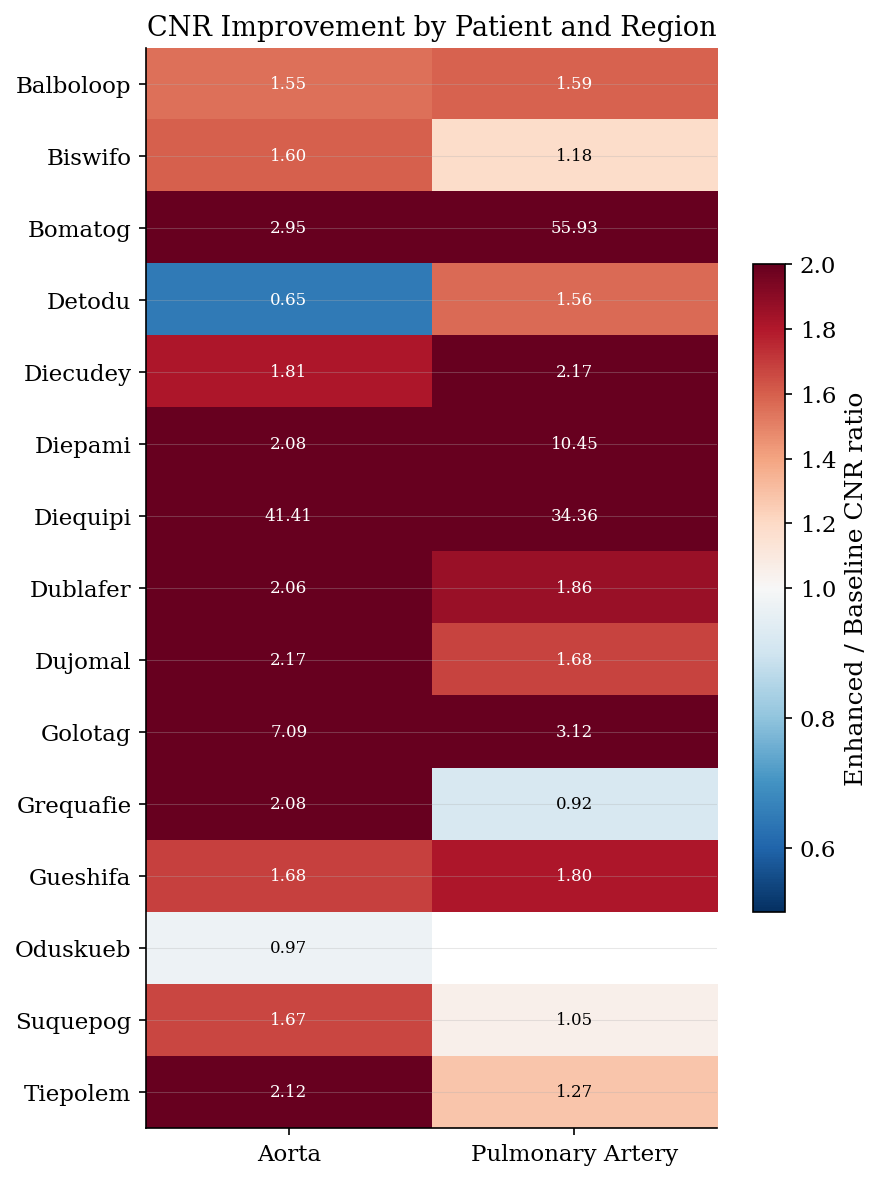

In [147]:
cnr_heatmap_data = (
    cnr_myo_pivot.reset_index()
    .pivot_table(index="patient", columns="region", values="vse_over_normal")
    .sort_index()
)

RATIO_VMIN, RATIO_VMAX = 0.5, 2.0
norm = TwoSlopeNorm(vmin=RATIO_VMIN, vcenter=1.0, vmax=RATIO_VMAX)
clipped = cnr_heatmap_data.clip(RATIO_VMIN, RATIO_VMAX)

fig, ax = plt.subplots(figsize=(6, 8))
im = ax.imshow(clipped.values, cmap="RdBu_r", norm=norm, aspect="auto")

ax.set_xticks(range(len(cnr_heatmap_data.columns)))
ax.set_xticklabels([REGION_LABELS.get(c, c) for c in cnr_heatmap_data.columns])
ax.set_yticks(range(len(cnr_heatmap_data.index)))
ax.set_yticklabels(cnr_heatmap_data.index)

for i in range(len(cnr_heatmap_data.index)):
    for j in range(len(cnr_heatmap_data.columns)):
        val = cnr_heatmap_data.iloc[i, j]
        if pd.notna(val):
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8,
                    color="white" if abs(val - 1.0) > 0.3 else "black")

fig.colorbar(im, ax=ax, shrink=0.6, label="Enhanced / Baseline CNR ratio")
ax.set_title("CNR Improvement by Patient and Region", fontsize=13)
fig.tight_layout()
plt.show()

---

# 2. Quality check: VSE preserves SNR

Enhancement is not expected to increase SNR — the goal is to confirm that the
Enhanced reconstruction does not degrade signal-to-noise ratio relative to Baseline.

### 2a. SNR distribution: Baseline vs. Enhanced by region

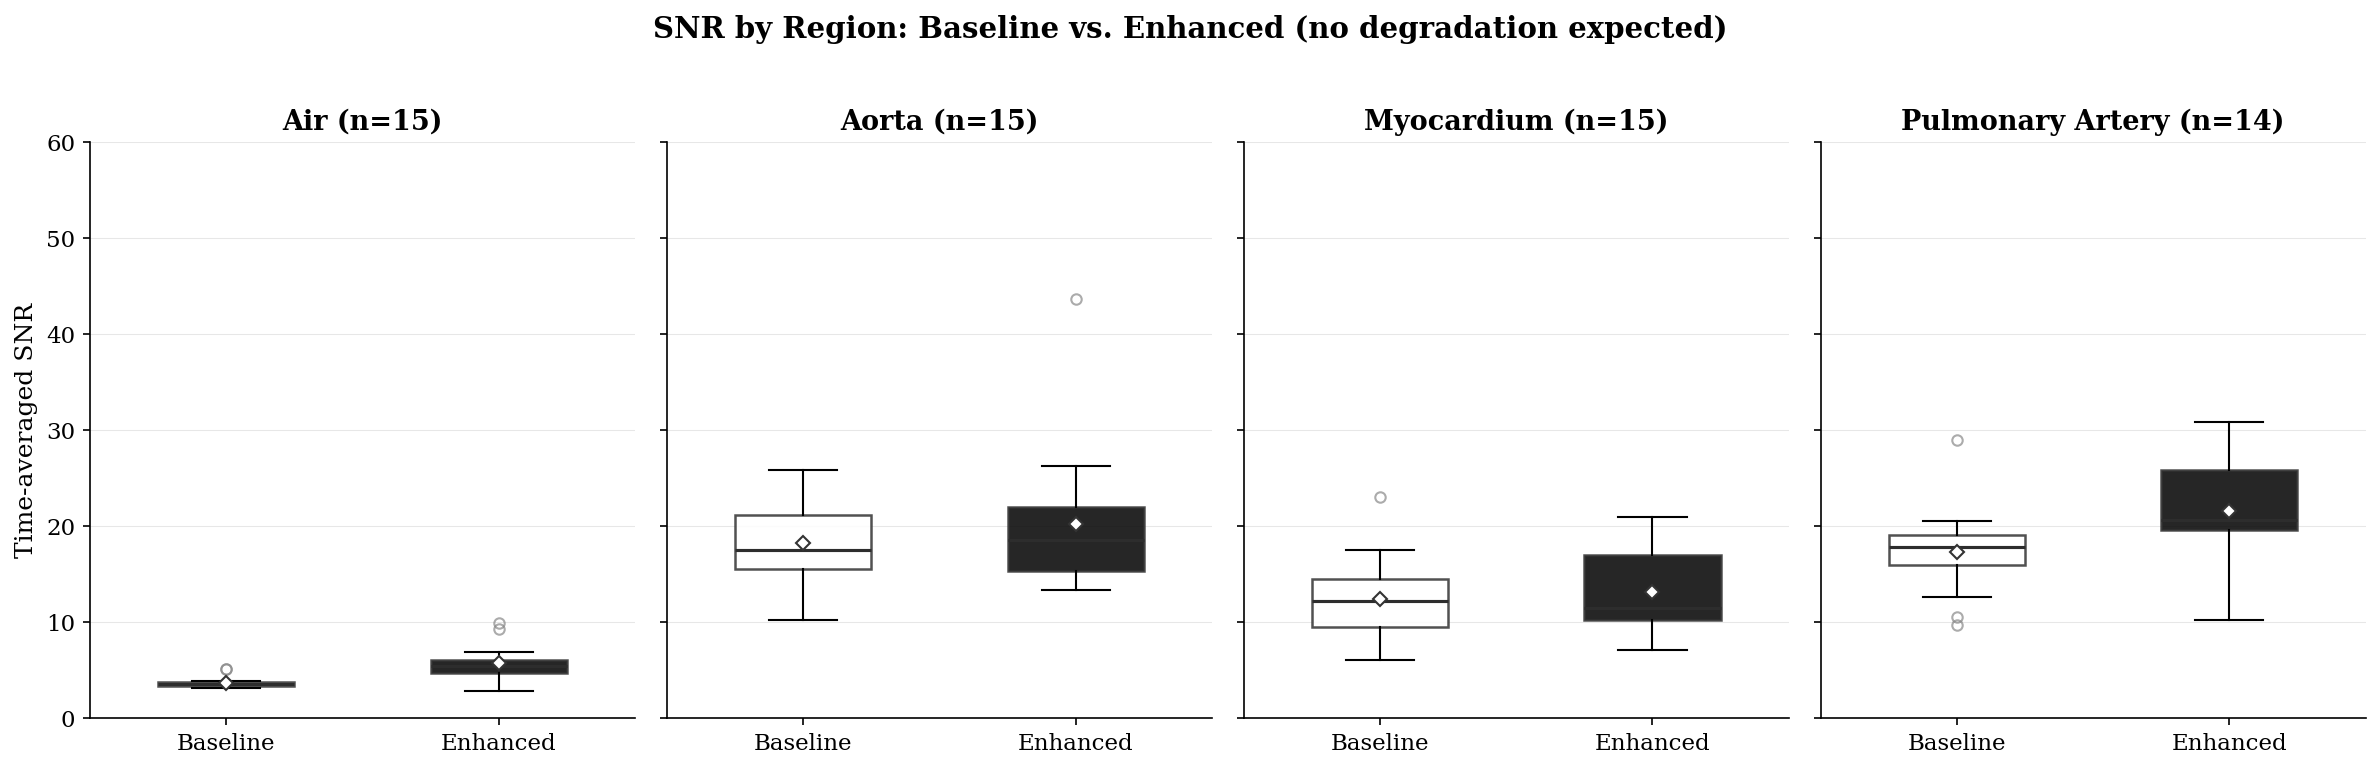

In [148]:
SNR_YLIM = (0, 60)

fig, axes = plt.subplots(1, len(regions), figsize=(4 * len(regions), 5), sharey=True)

for ax, region in zip(axes, regions):
    subset = snr_avg[snr_avg["region"] == region]
    normal = subset[subset["reconstruction"] == "normal"]["snr_mean"]
    vse = subset[subset["reconstruction"] == "vse"]["snr_mean"]

    bp = ax.boxplot([normal, vse], positions=[0, 1], widths=0.5, **BOXPLOT_KW)
    color_boxes(bp, [COLORS["normal"], COLORS["vse"]])

    ax.set_xticks([0, 1])
    ax.set_xticklabels([LABELS["normal"], LABELS["vse"]])
    ax.set_title(f"{REGION_LABELS[region]} (n={len(normal)})", fontweight="bold")
    ax.set_ylim(SNR_YLIM)

    n_clipped = int((normal > SNR_YLIM[1]).sum() + (vse > SNR_YLIM[1]).sum())
    if n_clipped:
        ax.text(0.95, 0.95, f"{n_clipped} pts clipped",
                transform=ax.transAxes, ha="right", va="top", fontsize=8, color="gray")

axes[0].set_ylabel("Time-averaged SNR")
fig.suptitle("SNR by Region: Baseline vs. Enhanced (no degradation expected)",
             fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

### 2b. Paired patient-level SNR: Baseline → Enhanced

Each line connects one patient's time-averaged SNR under Baseline (left) to Enhanced (right).
Near-horizontal lines indicate SNR is preserved.

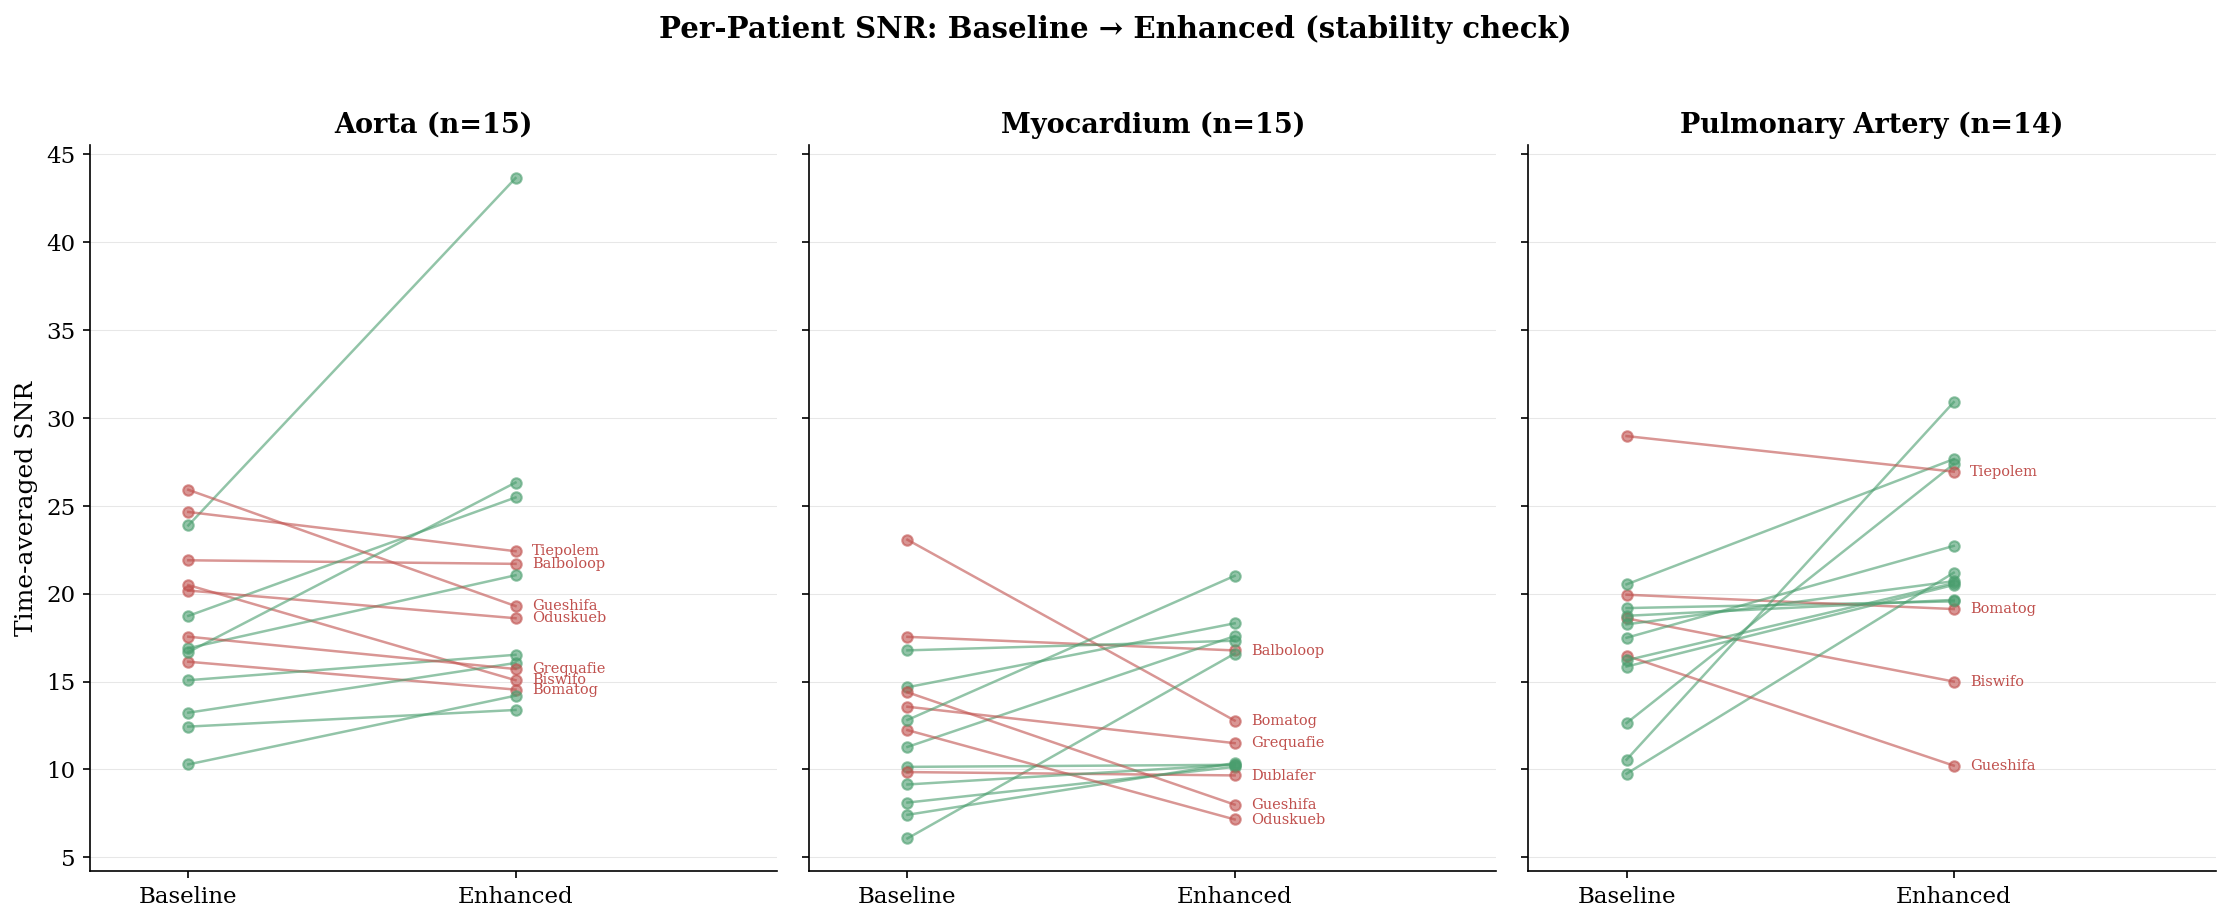

In [149]:
_paired_plot(snr_pivot, vessel_regions,
             "Time-averaged SNR", "Per-Patient SNR: Baseline → Enhanced (stability check)")

### 2c. SNR summary statistics & Enhanced/Baseline ratio

In [150]:
snr_summary = (
    snr_avg.groupby(["region", "reconstruction"])["snr_mean"]
    .agg(["mean", "std", "min", "max", "count"])
    .round(2)
)
print("Time-averaged SNR summary (across patients):")
display(snr_summary)

snr_ratio_by_region = (
    snr_pivot.reset_index()
    .groupby("region")["vse_over_normal"]
    .agg(["mean", "std"])
    .round(3)
    .rename(columns={"mean": "ratio_mean", "std": "ratio_std"})
)
print("\nEnhanced/Baseline SNR ratio (≈1.0 indicates preservation):")
display(snr_ratio_by_region)

Time-averaged SNR summary (across patients):


mean   std    min    max  count
region reconstruction                                  
Air    normal           3.73  0.63   3.12   5.18     15
       vse              5.74  1.92   2.86   9.96     15
Ao     normal          18.27  4.60  10.28  25.91     15
       vse             20.27  7.64  13.38  43.65     15
IVS    normal          12.47  4.45   6.07  23.07     15
       vse             13.18  4.32   7.15  21.01     15
PA     normal          17.37  4.72   9.76  28.97     14
       vse             21.58  5.38  10.21  30.90     14


Enhanced/Baseline SNR ratio (≈1.0 indicates preservation):


,ratio_mean,ratio_std
region,,
Air,1.589,0.615
Ao,1.125,0.311
IVS,1.165,0.548
PA,1.357,0.635


---

# 3. Supporting analyses

### 3a. Time curves over the cardiac cycle

Mean SI, SNR, and CNR over the 20 cardiac timepoints, Baseline vs. Enhanced, with
median and IQR shading. All subplots within each metric share the same y-axis
scale for direct comparison across regions.

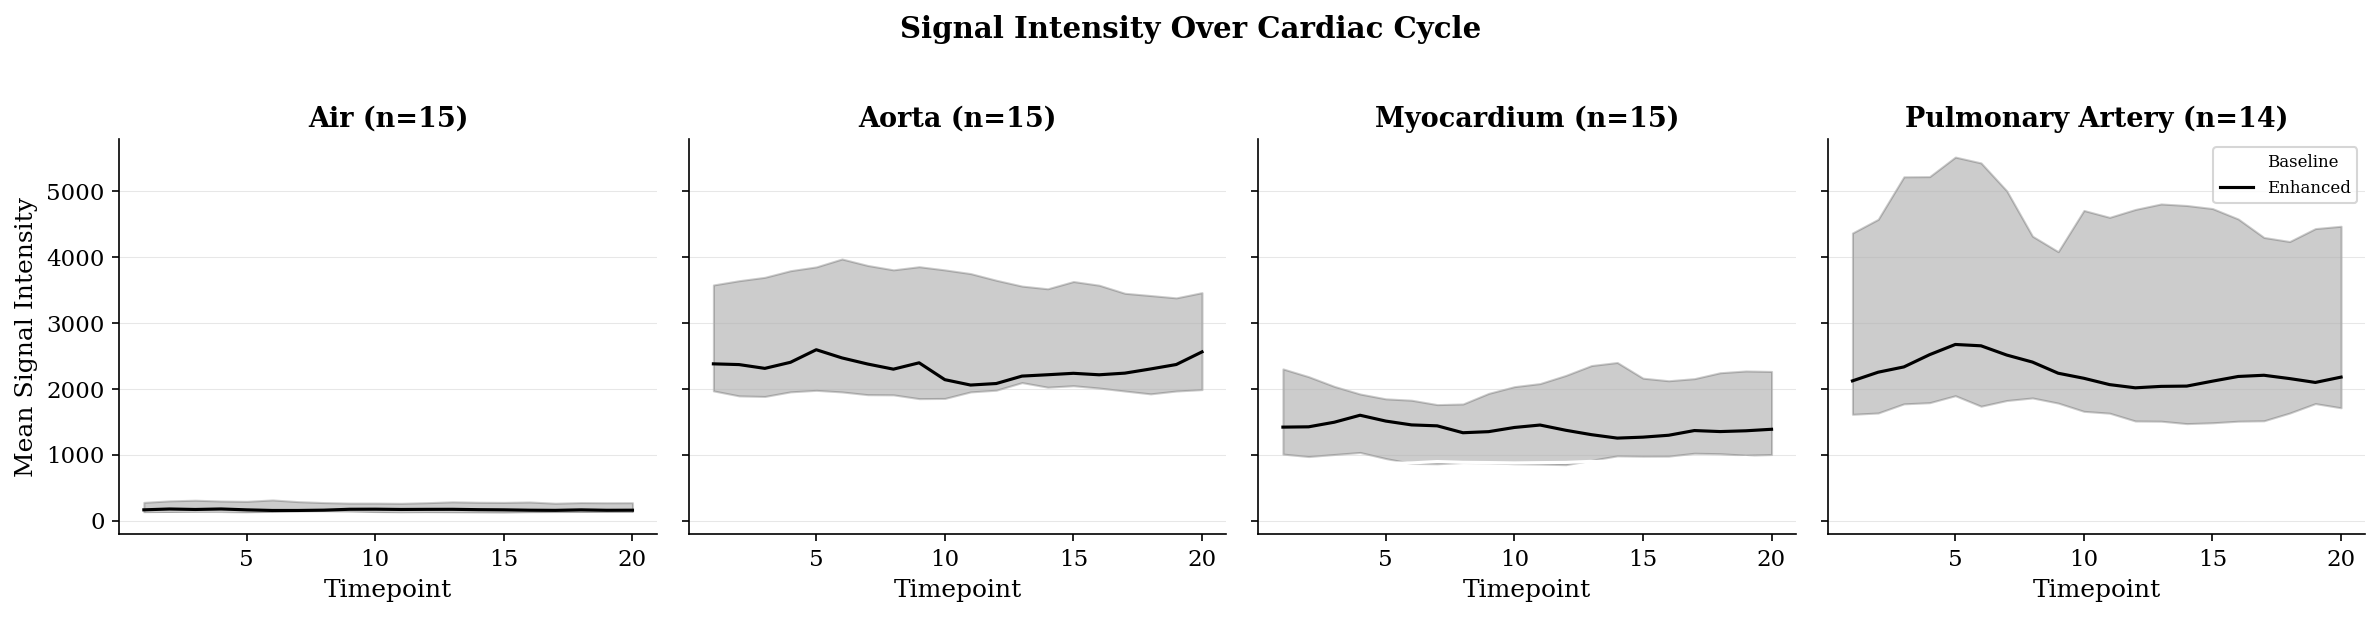

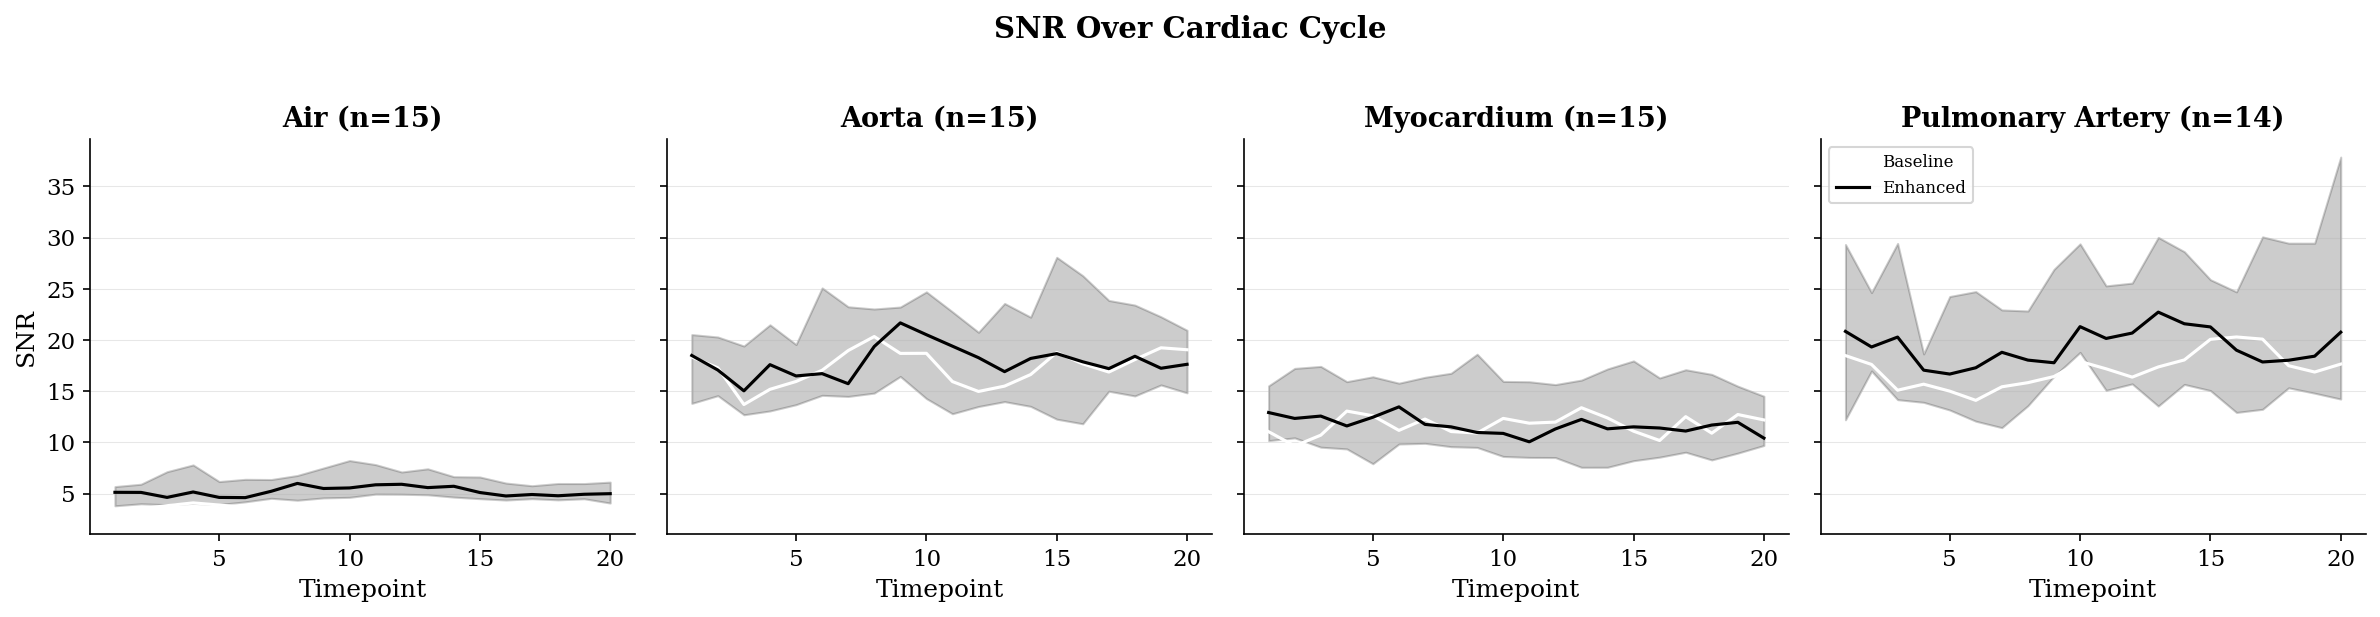

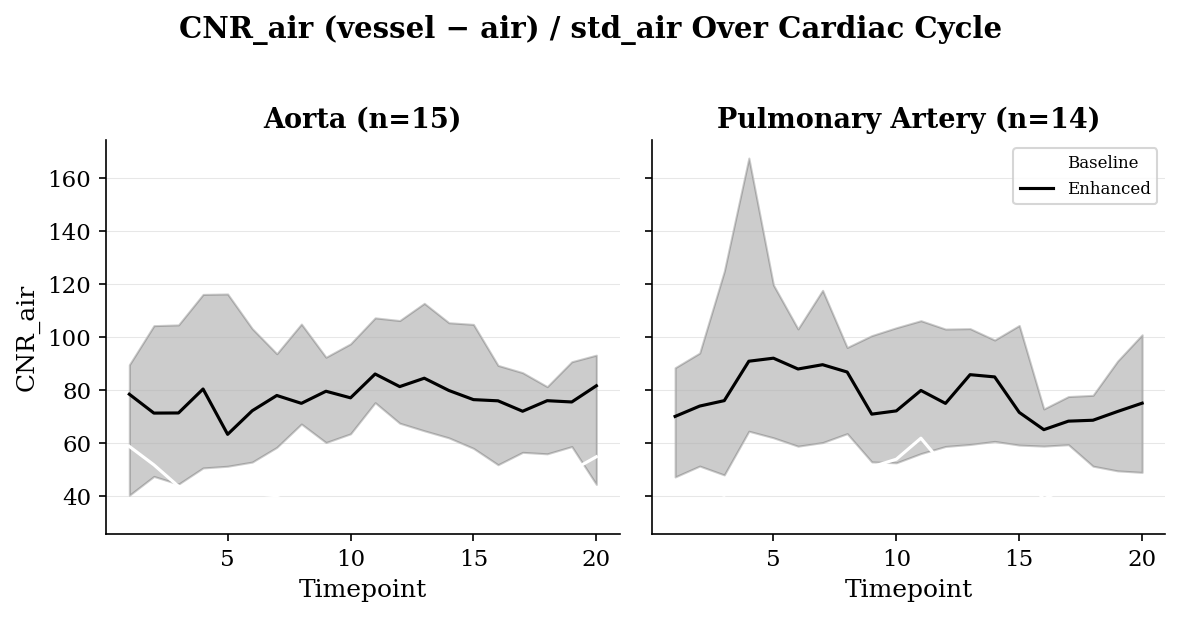

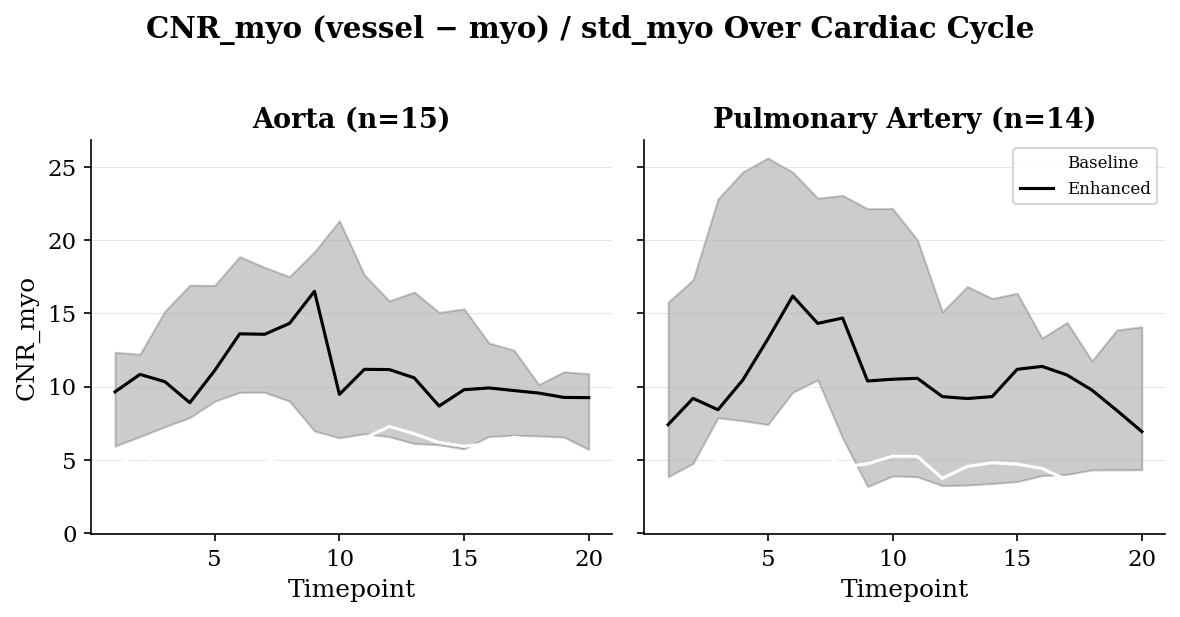

In [151]:
def _time_curve(ax, sub_data, value_col):
    """Plot Baseline vs Enhanced time curves with median and IQR shading."""
    for recon, color in COLORS.items():
        sub = sub_data[sub_data["reconstruction"] == recon]
        grouped = sub.groupby("timepoint")[value_col]
        med = grouped.median()
        q1 = grouped.quantile(0.25)
        q3 = grouped.quantile(0.75)
        ax.plot(med.index, med.values, color=color, label=LABELS[recon], linewidth=1.5)
        ax.fill_between(med.index, q1.values, q3.values, color=color, alpha=0.2)

# --- Signal Intensity ---
fig, axes = plt.subplots(1, len(regions), figsize=(4 * len(regions), 4), sharey=True)
for ax, region in zip(axes, regions):
    _time_curve(ax, data[data["region"] == region], "mean")
    n_reg = data[data["region"] == region]["patient"].nunique(); ax.set_title(f"{REGION_LABELS[region]} (n={n_reg})", fontweight="bold")
    ax.set_xlabel("Timepoint")
axes[0].set_ylabel("Mean Signal Intensity")
axes[-1].legend(fontsize=8)
fig.suptitle("Signal Intensity Over Cardiac Cycle", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

# --- SNR ---
fig, axes = plt.subplots(1, len(regions), figsize=(4 * len(regions), 4), sharey=True)
for ax, region in zip(axes, regions):
    _time_curve(ax, data[data["region"] == region], "snr")
    n_reg = data[data["region"] == region]["patient"].nunique(); ax.set_title(f"{REGION_LABELS[region]} (n={n_reg})", fontweight="bold")
    ax.set_xlabel("Timepoint")
axes[0].set_ylabel("SNR")
axes[-1].legend(fontsize=8)
fig.suptitle("SNR Over Cardiac Cycle", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

# --- CNR_air (Ao + PA only) ---
fig, axes = plt.subplots(1, len(cnr_regions), figsize=(4 * len(cnr_regions), 4), sharey=True)
for ax, region in zip(axes, cnr_regions):
    _time_curve(ax, cnr_air_data[cnr_air_data["region"] == region], "cnr")
    n_reg = data[data["region"] == region]["patient"].nunique(); ax.set_title(f"{REGION_LABELS[region]} (n={n_reg})", fontweight="bold")
    ax.set_xlabel("Timepoint")
axes[0].set_ylabel("CNR_air")
axes[-1].legend(fontsize=8)
fig.suptitle("CNR_air (vessel − air) / std_air Over Cardiac Cycle",
             fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

# --- CNR_myo (Ao + PA only) ---
fig, axes = plt.subplots(1, len(cnr_regions), figsize=(4 * len(cnr_regions), 4), sharey=True)
for ax, region in zip(axes, cnr_regions):
    _time_curve(ax, cnr_myo_data[cnr_myo_data["region"] == region], "cnr")
    n_reg = data[data["region"] == region]["patient"].nunique(); ax.set_title(f"{REGION_LABELS[region]} (n={n_reg})", fontweight="bold")
    ax.set_xlabel("Timepoint")
axes[0].set_ylabel("CNR_myo")
axes[-1].legend(fontsize=8)
fig.suptitle("CNR_myo (vessel − myo) / std_myo Over Cardiac Cycle",
             fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

### 3b. Grouped summary bar plots

Mean SI, SNR, and CNR grouped by region with Baseline vs. Enhanced bars and SD error bars.

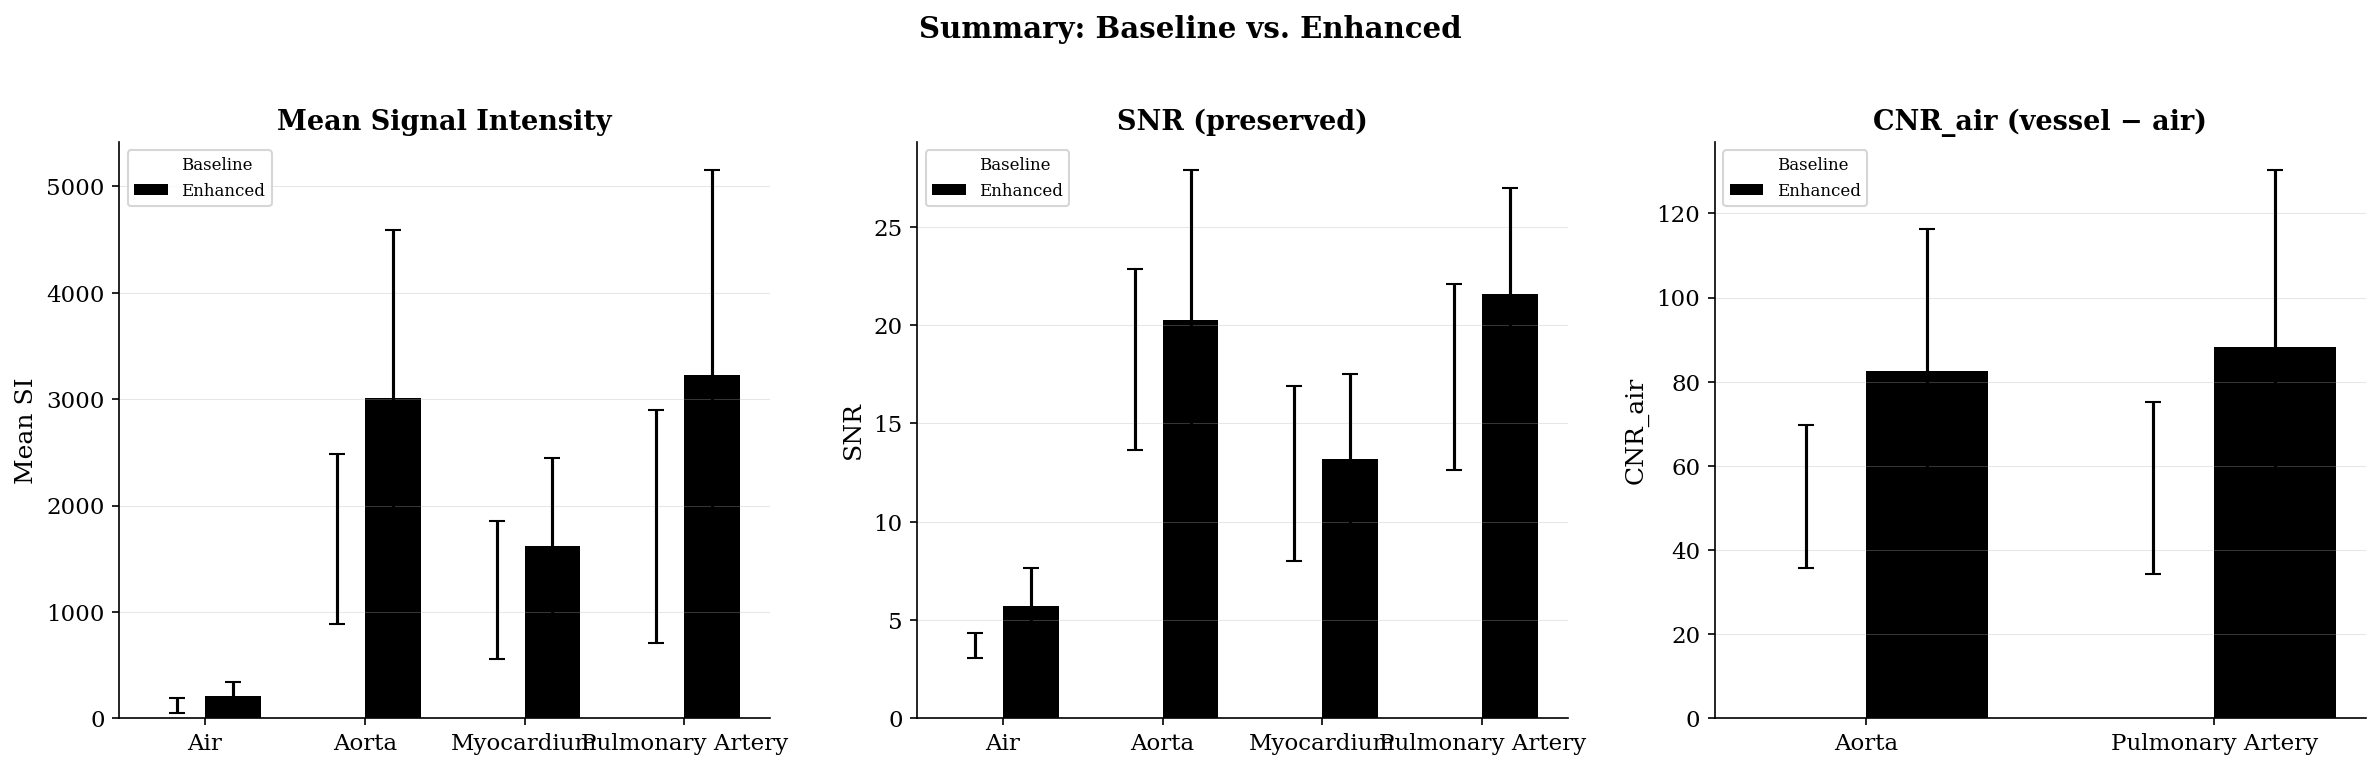

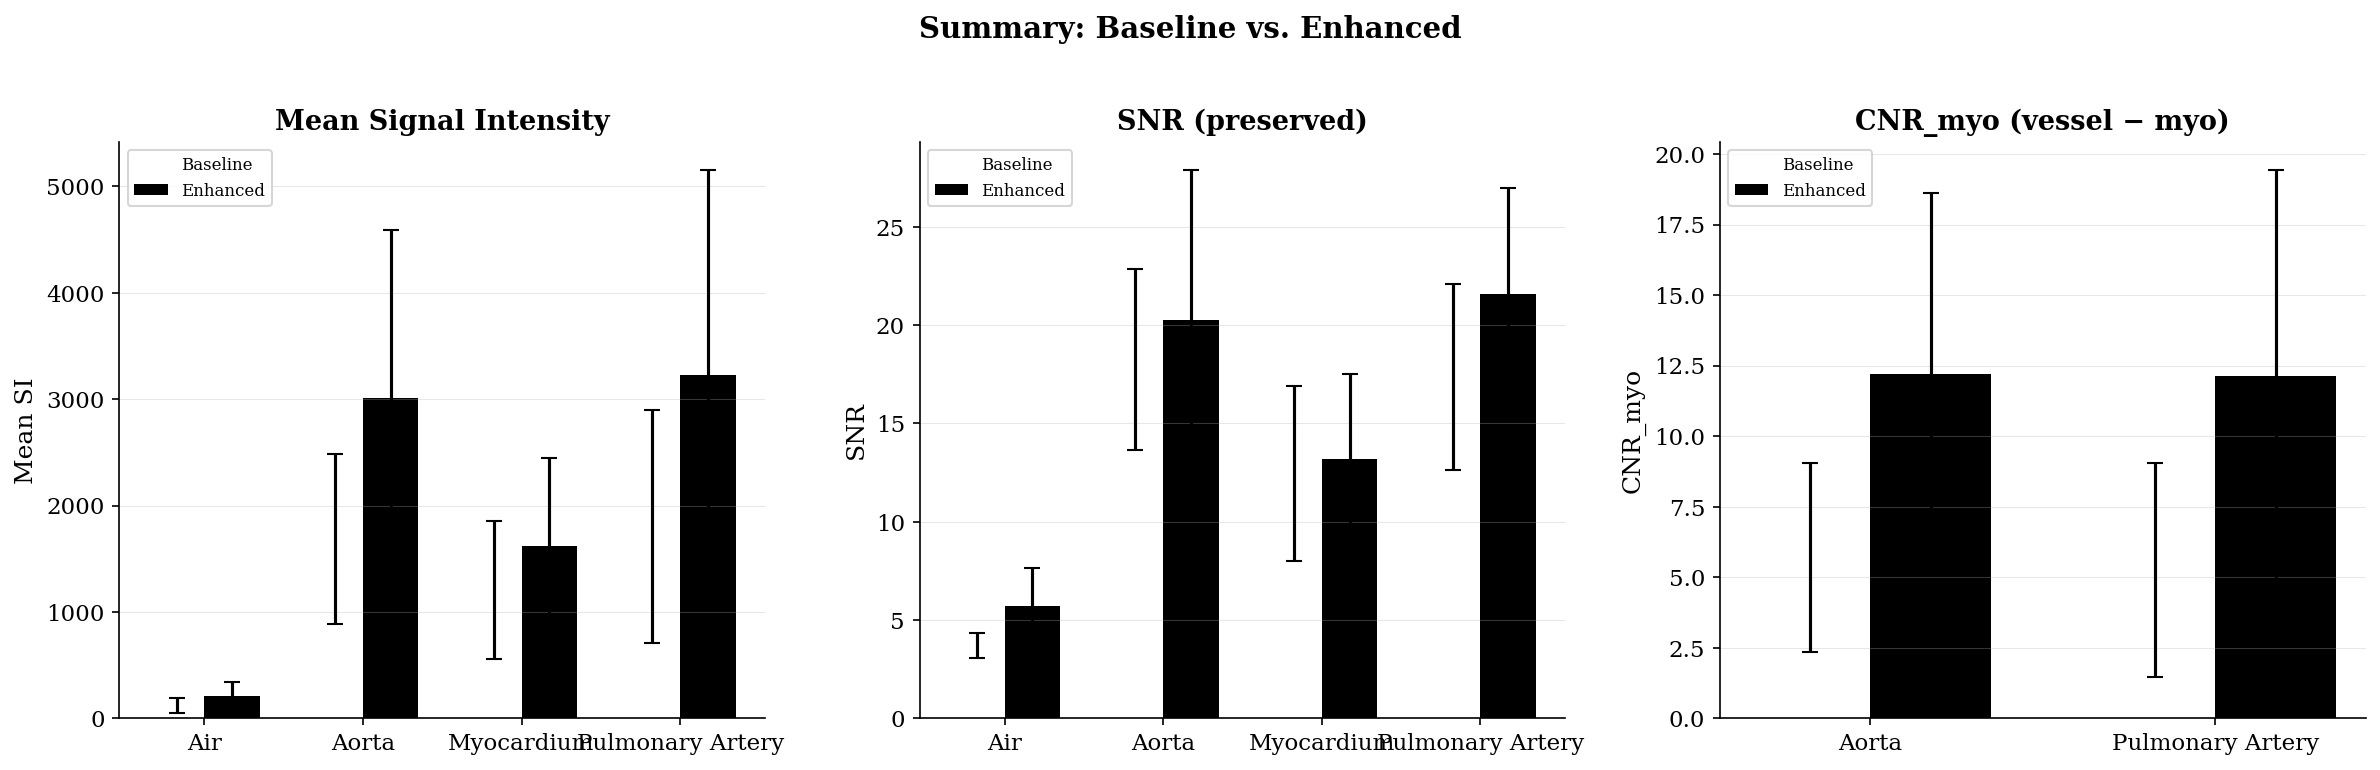

In [152]:
def _bar_data(df, value_col, region_list):
    """Return (means_normal, sds_normal, means_vse, sds_vse) for each region."""
    mn, sn, mv, sv = [], [], [], []
    for region in region_list:
        for recon, m_list, s_list in [("normal", mn, sn), ("vse", mv, sv)]:
            vals = df[(df["region"] == region) & (df["reconstruction"] == recon)][value_col]
            m_list.append(vals.mean())
            s_list.append(vals.std())
    return mn, sn, mv, sv

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
bar_width = 0.35

# Mean SI (all regions)
ax = axes[0]
mn, sn, mv, sv = _bar_data(si_avg, "si_mean", regions)
x = np.arange(len(regions))
ax.bar(x - bar_width / 2, mn, bar_width, yerr=sn, capsize=4, color=COLORS["normal"], label=LABELS["normal"])
ax.bar(x + bar_width / 2, mv, bar_width, yerr=sv, capsize=4, color=COLORS["vse"], label=LABELS["vse"])
ax.set_xticks(x)
ax.set_xticklabels([REGION_LABELS[r] for r in regions])
ax.set_ylabel("Mean SI")
ax.set_title("Mean Signal Intensity", fontweight="bold")
ax.legend(fontsize=8)

# SNR (all regions)
ax = axes[1]
mn, sn, mv, sv = _bar_data(snr_avg, "snr_mean", regions)
ax.bar(x - bar_width / 2, mn, bar_width, yerr=sn, capsize=4, color=COLORS["normal"], label=LABELS["normal"])
ax.bar(x + bar_width / 2, mv, bar_width, yerr=sv, capsize=4, color=COLORS["vse"], label=LABELS["vse"])
ax.set_xticks(x)
ax.set_xticklabels([REGION_LABELS[r] for r in regions])
ax.set_ylabel("SNR")
ax.set_title("SNR (preserved)", fontweight="bold")
ax.legend(fontsize=8)

# CNR_air (Ao + PA only)
ax = axes[2]
xv = np.arange(len(cnr_regions))
mn, sn, mv, sv = _bar_data(cnr_air_avg, "cnr_mean", cnr_regions)
ax.bar(xv - bar_width / 2, mn, bar_width, yerr=sn, capsize=4, color=COLORS["normal"], label=LABELS["normal"])
ax.bar(xv + bar_width / 2, mv, bar_width, yerr=sv, capsize=4, color=COLORS["vse"], label=LABELS["vse"])
ax.set_xticks(xv)
ax.set_xticklabels([REGION_LABELS[r] for r in cnr_regions])
ax.set_ylabel("CNR_air")
ax.set_title("CNR_air (vessel − air)", fontweight="bold")
ax.legend(fontsize=8)

fig.suptitle("Summary: Baseline vs. Enhanced", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

# Same layout but with CNR_myo
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
mn, sn, mv, sv = _bar_data(si_avg, "si_mean", regions)
ax.bar(x - bar_width / 2, mn, bar_width, yerr=sn, capsize=4, color=COLORS["normal"], label=LABELS["normal"])
ax.bar(x + bar_width / 2, mv, bar_width, yerr=sv, capsize=4, color=COLORS["vse"], label=LABELS["vse"])
ax.set_xticks(x)
ax.set_xticklabels([REGION_LABELS[r] for r in regions])
ax.set_ylabel("Mean SI")
ax.set_title("Mean Signal Intensity", fontweight="bold")
ax.legend(fontsize=8)

ax = axes[1]
mn, sn, mv, sv = _bar_data(snr_avg, "snr_mean", regions)
ax.bar(x - bar_width / 2, mn, bar_width, yerr=sn, capsize=4, color=COLORS["normal"], label=LABELS["normal"])
ax.bar(x + bar_width / 2, mv, bar_width, yerr=sv, capsize=4, color=COLORS["vse"], label=LABELS["vse"])
ax.set_xticks(x)
ax.set_xticklabels([REGION_LABELS[r] for r in regions])
ax.set_ylabel("SNR")
ax.set_title("SNR (preserved)", fontweight="bold")
ax.legend(fontsize=8)

ax = axes[2]
mn, sn, mv, sv = _bar_data(cnr_myo_avg, "cnr_mean", cnr_regions)
ax.bar(xv - bar_width / 2, mn, bar_width, yerr=sn, capsize=4, color=COLORS["normal"], label=LABELS["normal"])
ax.bar(xv + bar_width / 2, mv, bar_width, yerr=sv, capsize=4, color=COLORS["vse"], label=LABELS["vse"])
ax.set_xticks(xv)
ax.set_xticklabels([REGION_LABELS[r] for r in cnr_regions])
ax.set_ylabel("CNR_myo")
ax.set_title("CNR_myo (vessel − myo)", fontweight="bold")
ax.legend(fontsize=8)

fig.suptitle("Summary: Baseline vs. Enhanced", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

### 3c. Enhanced / Baseline SNR ratio heatmap

Rows = patients, columns = vessel regions. Values near 1.0 confirm SNR preservation.

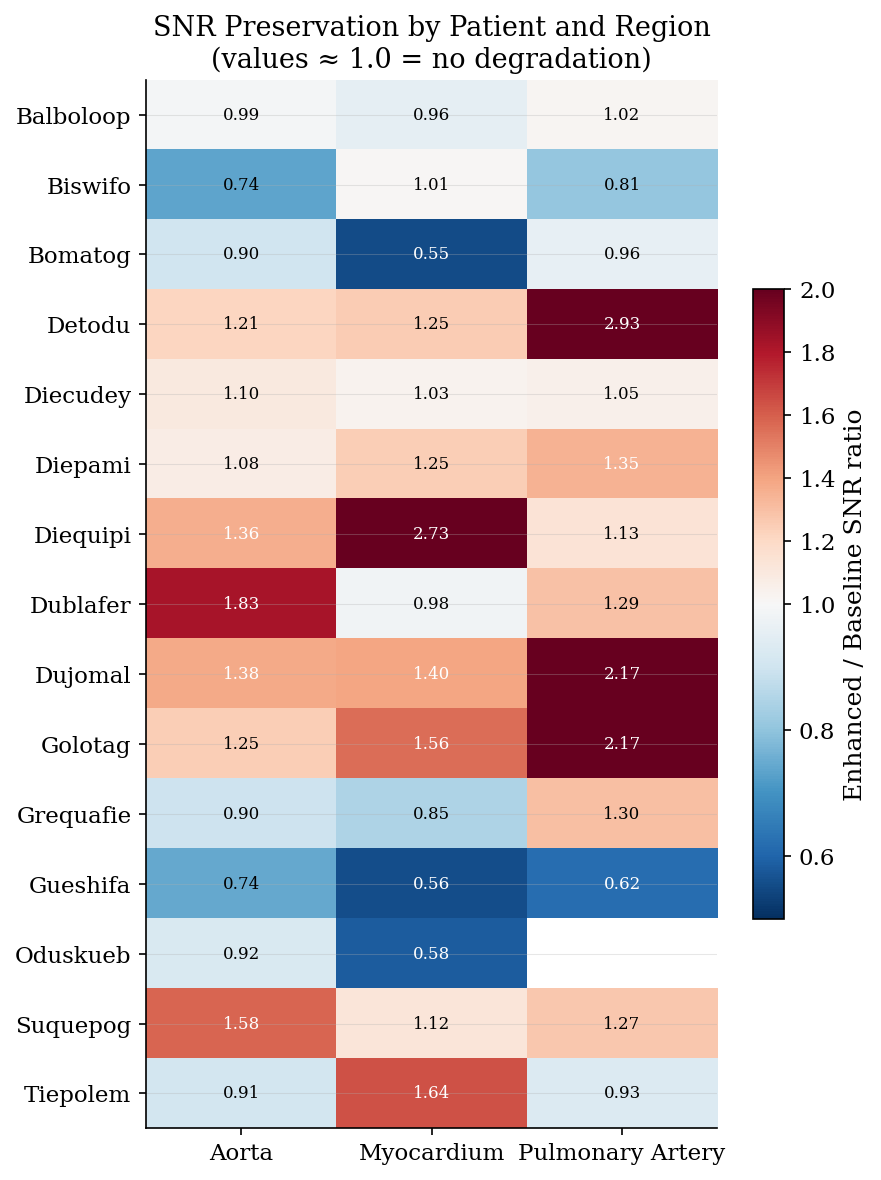

In [153]:
snr_heatmap_data = (
    snr_pivot.reset_index()
    .query("region != 'Air'")
    .pivot_table(index="patient", columns="region", values="vse_over_normal")
    .sort_index()
)

RATIO_VMIN, RATIO_VMAX = 0.5, 2.0
norm = TwoSlopeNorm(vmin=RATIO_VMIN, vcenter=1.0, vmax=RATIO_VMAX)
clipped = snr_heatmap_data.clip(RATIO_VMIN, RATIO_VMAX)

fig, ax = plt.subplots(figsize=(6, 8))
im = ax.imshow(clipped.values, cmap="RdBu_r", norm=norm, aspect="auto")

ax.set_xticks(range(len(snr_heatmap_data.columns)))
ax.set_xticklabels([REGION_LABELS.get(c, c) for c in snr_heatmap_data.columns])
ax.set_yticks(range(len(snr_heatmap_data.index)))
ax.set_yticklabels(snr_heatmap_data.index)

for i in range(len(snr_heatmap_data.index)):
    for j in range(len(snr_heatmap_data.columns)):
        val = snr_heatmap_data.iloc[i, j]
        if pd.notna(val):
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8,
                    color="white" if abs(val - 1.0) > 0.3 else "black")

fig.colorbar(im, ax=ax, shrink=0.6, label="Enhanced / Baseline SNR ratio")
ax.set_title("SNR Preservation by Patient and Region\n(values ≈ 1.0 = no degradation)", fontsize=13)
fig.tight_layout()
plt.show()

### 3d. Mixed-effects analysis: per-timepoint CNR and SNR

The time-averaged Wilcoxon tests (section 1c) collapse each patient to a single
value before testing, which naturally handles within-patient correlation but
discards temporal information.

A **linear mixed-effects model** with a random intercept per patient uses all
per-timepoint observations while properly accounting for repeated measures:

```
CNR ~ reconstruction + (1 | patient)
SNR ~ reconstruction + (1 | patient)
```

This analysis uses **all observations** (no SNR outlier exclusion) so that no
timepoints are discarded.

Key outputs:
- **effect** — the mean change in the metric when going from Baseline to Enhanced
- **ICC** (intra-class correlation) — fraction of total variance attributable to between-patient differences
- A direct comparison with the time-averaged and naïve per-timepoint Wilcoxon approaches

In [154]:
import warnings
import statsmodels.formula.api as smf

def _sig(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "ns"

def _pfmt(p):
    """Format p-value: scientific notation for small values."""
    if p < 0.0001:
        return f"{p:.2e}"
    return f"{p:.4f}"

# ── Build per-timepoint datasets (NO outlier exclusion — use all observations) ──
data_all = pd.read_csv(CSV_PATH)
data_all["snr"] = data_all["mean"] / data_all["std"]

vessels_all = data_all[data_all["region"].isin(cnr_regions)].copy()
ivs_all = data_all[data_all["region"] == "IVS"][
    ["patient", "reconstruction", "timepoint", "mean", "std"]
].rename(columns={"mean": "ivs_mean", "std": "ivs_std"})
cnr_all = vessels_all.merge(ivs_all, on=["patient", "reconstruction", "timepoint"], how="inner")
cnr_all["cnr"] = (cnr_all["mean"] - cnr_all["ivs_mean"]) / cnr_all["ivs_std"]

snr_tp = data_all[data_all["region"].isin(cnr_regions)][
    ["patient", "region", "reconstruction", "timepoint", "snr"]
].copy()
snr_tp["enhanced"] = (snr_tp["reconstruction"] == "vse").astype(int)

cnr_tp = cnr_all[["patient", "region", "reconstruction", "timepoint", "cnr"]].copy()
cnr_tp["enhanced"] = (cnr_tp["reconstruction"] == "vse").astype(int)

print(f"Using ALL timepoints (no SNR outlier filter):")
for region in cnr_regions:
    n_cnr = len(cnr_tp[cnr_tp["region"] == region])
    n_snr = len(snr_tp[snr_tp["region"] == region])
    n_pat_cnr = cnr_tp[cnr_tp["region"] == region]["patient"].nunique()
    print(f"  {region}: {n_cnr} CNR obs, {n_snr} SNR obs, {n_pat_cnr} patients")

# ── Fit mixed-effects models ──
me_rows = []
for metric_label, tp_df, value_col in [("CNR_myo", cnr_tp, "cnr"), ("SNR", snr_tp, "snr")]:
    for region in cnr_regions:
        sub = tp_df[tp_df["region"] == region].copy()
        md = smf.mixedlm(f"{value_col} ~ enhanced", sub, groups=sub["patient"])
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            result = md.fit(reml=True)

        coef = result.fe_params["enhanced"]
        pval = result.pvalues["enhanced"]
        ci = result.conf_int().loc["enhanced"]
        re_var = result.cov_re.iloc[0, 0]
        resid_var = result.scale
        icc = re_var / (re_var + resid_var) if (re_var + resid_var) > 0 else 0
        n_obs = len(sub)
        n_pat = sub["patient"].nunique()

        me_rows.append({
            "metric": metric_label,
            "region": region,
            "n_patients": n_pat,
            "n_obs": n_obs,
            "effect": coef,
            "ci_lo": ci[0],
            "ci_hi": ci[1],
            "p": pval,
            "τ² (patient)": re_var,
            "σ² (residual)": resid_var,
            "ICC": icc,
        })

me_df = pd.DataFrame(me_rows)

# ── Comparison: time-averaged Wilcoxon vs mixed-effects vs per-timepoint Wilcoxon ──
# Time-averaged pivots (recomputed from unfiltered data for consistency)
cnr_avg_all = cnr_all.groupby(["patient", "region", "reconstruction"])["cnr"].mean().reset_index()
cnr_pivot_all = cnr_avg_all.pivot_table(index=["patient", "region"], columns="reconstruction", values="cnr")

snr_avg_all = data_all[data_all["region"].isin(cnr_regions)].groupby(
    ["patient", "region", "reconstruction"])["snr"].mean().reset_index()
snr_pivot_all = snr_avg_all.pivot_table(index=["patient", "region"], columns="reconstruction", values="snr")

comparison_rows = []
for metric_label, pivot_df, tp_df, value_col in [
    ("CNR_myo", cnr_pivot_all, cnr_tp, "cnr"),
    ("SNR",     snr_pivot_all, snr_tp, "snr"),
]:
    for region in cnr_regions:
        pdf = pivot_df.reset_index()
        sub_avg = pdf[pdf["region"] == region].dropna(subset=["normal", "vse"])
        _, p_avg = sp_stats.wilcoxon(sub_avg["vse"].values - sub_avg["normal"].values)

        sub_tp = tp_df[tp_df["region"] == region]
        tp_piv = sub_tp.pivot_table(index=["patient", "timepoint"],
                                    columns="reconstruction", values=value_col).dropna()
        _, p_tp = sp_stats.wilcoxon(tp_piv["vse"].values - tp_piv["normal"].values)

        me_row = me_df[(me_df["metric"] == metric_label) & (me_df["region"] == region)].iloc[0]

        comparison_rows.append({
            "metric": metric_label, "region": region,
            "p_time_avg_wilcoxon": p_avg,
            "p_mixed_effects": me_row["p"],
            "p_per_tp_wilcoxon": p_tp,
        })

comparison_df = pd.DataFrame(comparison_rows)

# ── Display ──
print("\n" + "═" * 90)
print("  Mixed-Effects Model: metric ~ enhanced + (1 | patient)")
print("═" * 90)
print()
display(me_df.style.format({
    "effect": "{:+.2f}", "ci_lo": "{:.2f}", "ci_hi": "{:.2f}",
    "p": lambda p: f"{_pfmt(p)} ({_sig(p)})",
    "τ² (patient)": "{:.2f}", "σ² (residual)": "{:.2f}",
    "ICC": "{:.2f}",
}).hide(axis="index"))

print()
print("  effect  = mean change in metric when going from Baseline to Enhanced")
print("  τ²      = between-patient variance  (how much patients differ from each other)")
print("  σ²      = within-patient variance    (how much timepoints vary within a patient)")
print("  ICC     = τ² / (τ² + σ²)             (fraction of total variance due to patient)")
print()

print("═" * 90)
print("  Comparison: Time-Averaged Wilcoxon vs Mixed-Effects vs Per-Timepoint Wilcoxon")
print("═" * 90)
print()
comp_display = comparison_df.copy()
for col in ["p_time_avg_wilcoxon", "p_mixed_effects", "p_per_tp_wilcoxon"]:
    comp_display[col] = comparison_df[col].apply(lambda p: f"{_pfmt(p)} ({_sig(p)})")
display(comp_display.style.hide(axis="index"))

Using ALL timepoints (no SNR outlier filter):
  Ao: 600 CNR obs, 600 SNR obs, 15 patients
  PA: 560 CNR obs, 560 SNR obs, 14 patients

══════════════════════════════════════════════════════════════════════════════════════════
  Mixed-Effects Model: metric ~ enhanced + (1 | patient)
══════════════════════════════════════════════════════════════════════════════════════════



metric,region,n_patients,n_obs,effect,ci_lo,ci_hi,p,τ² (patient),σ² (residual),ICC
CNR_myo,Ao,15,600,+6.50,5.62,7.38,2.57e-47 (***),15.66,30.38,0.34
CNR_myo,PA,14,560,+7.73,6.64,8.82,4.91e-44 (***),28.12,43.19,0.39
SNR,Ao,15,600,+2.00,0.89,3.11,0.0004 (***),27.87,48.04,0.37
SNR,PA,14,560,+71.13,-51.05,193.31,0.2539 (ns),2122.84,544019.29,0.00



  effect  = mean change in metric when going from Baseline to Enhanced
  τ²      = between-patient variance  (how much patients differ from each other)
  σ²      = within-patient variance    (how much timepoints vary within a patient)
  ICC     = τ² / (τ² + σ²)             (fraction of total variance due to patient)

══════════════════════════════════════════════════════════════════════════════════════════
  Comparison: Time-Averaged Wilcoxon vs Mixed-Effects vs Per-Timepoint Wilcoxon
══════════════════════════════════════════════════════════════════════════════════════════



metric,region,p_time_avg_wilcoxon,p_mixed_effects,p_per_tp_wilcoxon
CNR_myo,Ao,0.0003 (***),2.57e-47 (***),2.09e-39 (***)
CNR_myo,PA,0.0004 (***),4.91e-44 (***),6.61e-33 (***)
SNR,Ao,0.4543 (ns),0.0004 (***),0.0089 (**)
SNR,PA,0.0580 (ns),0.2539 (ns),1.98e-07 (***)
